# ISIC 2024 — Phase 1: Exploratory Data Analysis

**Purpose:** Every preprocessing decision in this project must be justified by evidence from this notebook.  
When someone asks *"why did you drop mel_thick_mm?"* → Section 4, Cell 4.1.  
When they ask *"why median imputation for age?"* → Section 5, Cell 5.2.  

The Decisions Summary in Section 10 is the key deliverable — it is the evidence-based contract that the Preprocessor (Step 3) must implement.

**Data:** `data/raw/isic-2024-challenge/train-metadata.csv`  
**Imports:** pandas, numpy, matplotlib, seaborn, sklearn.metrics only — no custom modules yet.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

# ── Resolve data path ─────────────────────────────────────────────────────────
# Checks candidate locations in order; works locally, in Colab, and on Kaggle.
_RELATIVE = Path('data') / 'raw' / 'isic-2024-challenge' / 'train-metadata.csv'

_CANDIDATES = [
    Path.cwd() / _RELATIVE,                        # launched from project root
    Path.cwd().parent / _RELATIVE,                 # launched from notebooks/
    Path('/content') / _RELATIVE,                  # Google Colab
    Path('/kaggle/input/isic-2024-challenge/train-metadata.csv'),  # Kaggle
]

DATA_PATH = next((p for p in _CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "train-metadata.csv not found. Expected at:\n"
        + "\n".join(f"  {p}" for p in _CANDIDATES)
    )

PROJECT_ROOT = DATA_PATH.parents[3]   # .../data/raw/isic-2024-challenge/train-metadata.csv
print(f'Project root : {PROJECT_ROOT}')
print(f'Data path    : {DATA_PATH}')
print(f'File exists  : {DATA_PATH.exists()}')


Project root : /Users/deepanshumehta/Documents/Ai/Projects/ISIC2024
Data path    : /Users/deepanshumehta/Documents/Ai/Projects/ISIC2024/data/raw/isic-2024-challenge/train-metadata.csv
File exists  : True


---
## Section 1: Dataset Overview
**Question: What are we working with?**

In [2]:
# Cell 1.1 — Load data, print shape
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Shape: 401,059 rows × 55 columns


In [3]:
# Cell 1.2 — dtypes summary
dtype_summary = df.dtypes.value_counts()
print('Column dtype breakdown:')
for dtype, count in dtype_summary.items():
    print(f'  {str(dtype):<12} : {count} columns')

print('\nObject (string) columns:')
print([c for c in df.columns if df[c].dtype == 'object'])

Column dtype breakdown:
  float64      : 35 columns
  object       : 18 columns
  int64        : 2 columns

Object (string) columns:
['isic_id', 'patient_id', 'sex', 'anatom_site_general', 'image_type', 'tbp_tile_type', 'tbp_lv_location', 'tbp_lv_location_simple', 'attribution', 'copyright_license', 'lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'mel_mitotic_index']


In [4]:
# Cell 1.3 — Sample values (transposed for readability)
df.head(3).T

,0,1,2
isic_id,ISIC_0015670,ISIC_0015845,ISIC_0015864
target,0,0,0
patient_id,IP_1235828,IP_8170065,IP_6724798
age_approx,60.0,60.0,60.0
sex,male,male,male
anatom_site_general,lower extremity,head/neck,posterior torso
clin_size_long_diam_mm,3.04,1.1,3.4
image_type,TBP tile: close-up,TBP tile: close-up,TBP tile: close-up
tbp_tile_type,3D: white,3D: white,3D: XP
tbp_lv_A,20.244422,31.71257,22.57583


In [5]:
# Cell 1.4 — Numeric summary
pd.set_option('display.max_columns', None)
df.describe().T.sort_values('std', ascending=False).round(3)

,count,mean,std,min,25%,50%,75%,max
tbp_lv_y,401059.0,1039.598,409.820,-1052.134,746.520,1172.803,1342.132,1887.767
tbp_lv_x,401059.0,-3.092,197.258,-624.871,-147.022,-5.747,140.475,614.472
tbp_lv_z,401059.0,55.823,87.968,-291.890,-8.963,67.958,126.612,319.407
tbp_lv_symm_2axis_angle,401059.0,86.332,52.560,0.000,40.000,90.000,130.000,175.000
tbp_lv_nevi_confidence,401059.0,38.520,41.481,0.000,0.110,14.409,87.791,100.000
age_approx,398261.0,58.013,13.596,5.000,50.000,60.000,70.000,85.000
tbp_lv_Lext,401059.0,51.200,12.101,17.702,42.275,51.426,60.496,98.588
tbp_lv_L,401059.0,42.290,10.865,4.223,34.303,42.344,50.405,87.549
tbp_lv_areaMM2,401059.0,8.540,9.679,0.432,4.110,5.686,9.120,334.153
tbp_lv_dnn_lesion_confidence,401059.0,97.162,8.996,0.000,99.669,99.995,100.000,100.000


In [6]:
# Cell 1.5 — Column groups (discovered from actual column names)
cols = df.columns.tolist()

groups = {
    'Identifiers':        [c for c in cols if c in ('isic_id', 'patient_id', 'lesion_id')],
    'Target':             [c for c in cols if c == 'target'],
    'Demographics':       [c for c in cols if c in ('age_approx', 'sex')],
    'Location':           [c for c in cols if c in ('anatom_site_general', 'tbp_lv_location', 'tbp_lv_location_simple')],
    'Clinical size':      [c for c in cols if 'clin_size' in c],
    'Diagnosis info':     [c for c in cols if c.startswith('iddx_') or c.startswith('diagnosis')],
    'Melanoma-specific':  [c for c in cols if c in ('mel_thick_mm', 'mel_mitotic_index')],
    'TBP color (raw)':    [c for c in cols if c.startswith('tbp_lv_') and
                           any(c.endswith(s) for s in ('_A','_B','_C','_H','_L','Aext','Bext','Cext','Hext','Lext'))],
    'TBP color deltas':   [c for c in cols if 'delta' in c.lower() and c.startswith('tbp_lv_')],
    'TBP shape/size':     [c for c in cols if c in ('tbp_lv_areaMM2','tbp_lv_perimeterMM',
                           'tbp_lv_minorAxisMM','tbp_lv_eccentricity','tbp_lv_symm_2axis',
                           'tbp_lv_symm_2axis_angle','tbp_lv_norm_border','tbp_lv_area_perim_ratio')],
    'TBP color variation':[c for c in cols if c in ('tbp_lv_color_std_mean','tbp_lv_radial_color_std_max',
                           'tbp_lv_stdL','tbp_lv_stdLExt','tbp_lv_norm_color')],
    'TBP AI scores':      [c for c in cols if c in ('tbp_lv_nevi_confidence','tbp_lv_dnn_lesion_confidence')],
    'TBP 3D coords':      [c for c in cols if c in ('tbp_lv_x','tbp_lv_y','tbp_lv_z')],
    'Metadata/admin':     [c for c in cols if c in ('attribution','image_type','tbp_tile_type',
                           'copyright_license')],
}

# Catch any columns not yet categorised
assigned = {c for grp in groups.values() for c in grp}
groups['Uncategorised'] = [c for c in cols if c not in assigned]

total_assigned = 0
for grp, members in groups.items():
    if members:
        print(f'\n[{grp}] ({len(members)} cols)')
        for m in members:
            print(f'  {m}')
        total_assigned += len(members)
print(f'\nTotal: {total_assigned} / {len(cols)} columns categorised')


[Identifiers] (3 cols)
  isic_id
  patient_id
  lesion_id

[Target] (1 cols)
  target

[Demographics] (2 cols)
  age_approx
  sex

[Location] (3 cols)
  anatom_site_general
  tbp_lv_location
  tbp_lv_location_simple

[Clinical size] (1 cols)
  clin_size_long_diam_mm

[Diagnosis info] (6 cols)
  iddx_full
  iddx_1
  iddx_2
  iddx_3
  iddx_4
  iddx_5

[Melanoma-specific] (2 cols)
  mel_mitotic_index
  mel_thick_mm

[TBP color (raw)] (10 cols)
  tbp_lv_A
  tbp_lv_Aext
  tbp_lv_B
  tbp_lv_Bext
  tbp_lv_C
  tbp_lv_Cext
  tbp_lv_H
  tbp_lv_Hext
  tbp_lv_L
  tbp_lv_Lext

[TBP color deltas] (5 cols)
  tbp_lv_deltaA
  tbp_lv_deltaB
  tbp_lv_deltaL
  tbp_lv_deltaLB
  tbp_lv_deltaLBnorm

[TBP shape/size] (8 cols)
  tbp_lv_areaMM2
  tbp_lv_area_perim_ratio
  tbp_lv_eccentricity
  tbp_lv_minorAxisMM
  tbp_lv_norm_border
  tbp_lv_perimeterMM
  tbp_lv_symm_2axis
  tbp_lv_symm_2axis_angle

[TBP color variation] (5 cols)
  tbp_lv_color_std_mean
  tbp_lv_norm_color
  tbp_lv_radial_color_std_max
  tbp_l

### Finding 1

**Discovered:**
- Total rows: `401,059`, columns: `55`
- Dtype breakdown: `35` float64, `2` int64, `18` object
- Column groups: identifiers (3), target (1), demographics (2), location (3), clinical size (1), diagnosis/leakage (~7), TBP color raw (~10), TBP deltas (~5), TBP shape/size (~8), TBP color variation (~5), TBP AI scores (2), TBP 3D coords (3), metadata/admin (~4)
- The `tbp_lv_*` columns encode the ABCDE criteria as machine-extracted numeric measurements — not arbitrary metadata.

---
## Section 2: Target Variable
**Question: How severe is the class imbalance?**

In [7]:
# Cell 2.1 — Exact counts
vc = df['target'].value_counts()
total = len(df)
n_mal = vc.get(1, 0)
n_ben = vc.get(0, 0)
pct = n_mal / total * 100

print(f'Total lesions  : {total:,}')
print(f'Benign  (0)    : {n_ben:,}  ({n_ben/total*100:.4f}%)')
print(f'Malignant (1)  : {n_mal:,}   ({pct:.4f}%)')
print(f'Imbalance ratio: 1 malignant per {n_ben/n_mal:.0f} benign lesions')

Total lesions  : 401,059
Benign  (0)    : 400,666  (99.9020%)
Malignant (1)  : 393   (0.0980%)
Imbalance ratio: 1 malignant per 1020 benign lesions


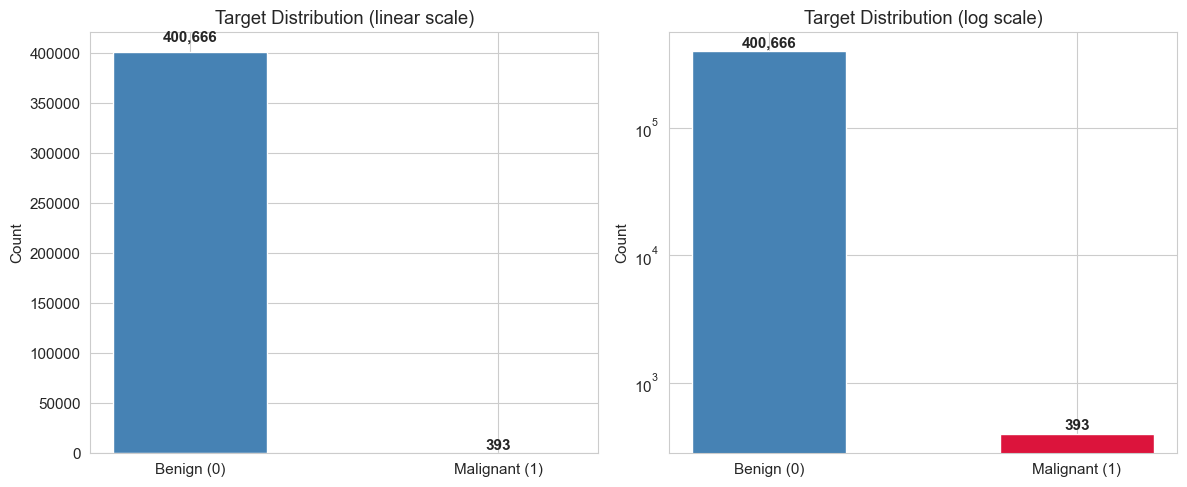

In [8]:
# Cell 2.2 — Bar charts: normal scale + log scale
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Benign (0)', 'Malignant (1)']
counts = [n_ben, n_mal]
colors = ['steelblue', 'crimson']

for ax, yscale in zip(axes, ['linear', 'log']):
    bars = ax.bar(labels, counts, color=colors, edgecolor='white', width=0.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{cnt:,}', ha='center', va='bottom', fontweight='bold')
    ax.set_yscale(yscale)
    ax.set_title(f'Target Distribution ({yscale} scale)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### Finding 2

**Discovered:**  
Malignant: `393` out of `401,059` total (`0.098%`).

For every 1 malignant lesion there are approximately `1,020` benign ones. This is one of the most extreme imbalances in medical ML.

**Implications for modeling:**
- `scale_pos_weight ≈ neg/pos` in LightGBM/XGBoost (use ~1020)
- `auto_class_weights` or manual weights in CatBoost
- `class_weight='balanced'` in SVM
- `StratifiedGroupKFold` to ensure each fold has positive examples
- pAUC metric focuses on high-sensitivity region (TPR > 80%) where this imbalance matters most

---
## Section 3: Missing Values
**Question: Which columns have missing data, and how much?**

In [9]:
# Cell 3.1 — Missing % per column
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

print(f'Columns with any missing data: {len(missing_nonzero)} / {len(df.columns)}')
print()
print(f'{"Column":<40} {"Missing %":>10}  {"Missing N":>10}')
print('-' * 64)
for col, pct in missing_nonzero.items():
    n = df[col].isna().sum()
    print(f'{col:<40} {pct:>9.2f}%  {n:>10,}')

Columns with any missing data: 10 / 55

Column                                    Missing %   Missing N
----------------------------------------------------------------
iddx_5                                      100.00%     401,058
mel_mitotic_index                            99.99%     401,006
mel_thick_mm                                 99.98%     400,996
iddx_4                                       99.86%     400,508
iddx_3                                       99.73%     399,994
iddx_2                                       99.73%     399,991
lesion_id                                    94.50%     379,001
sex                                           2.87%      11,517
anatom_site_general                           1.44%       5,756
age_approx                                    0.70%       2,798


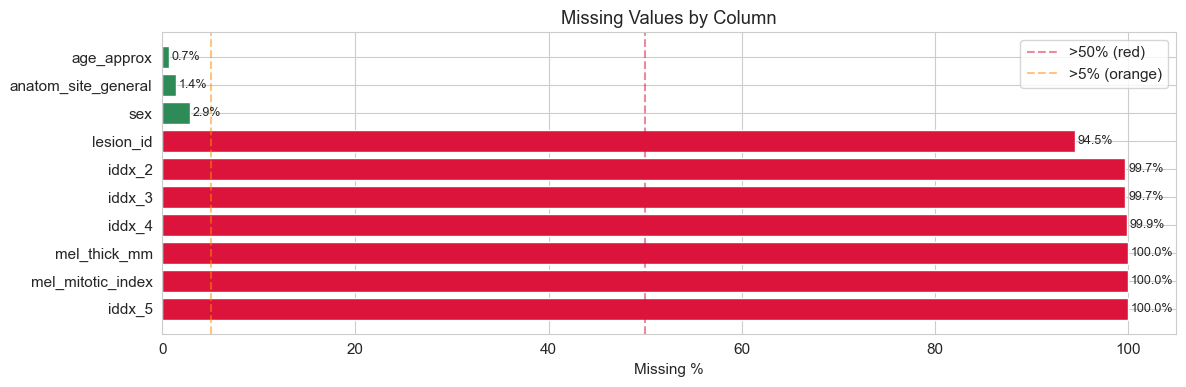

In [10]:
# Cell 3.2 — Horizontal bar chart of missing %
if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(missing_nonzero) * 0.4)))

    bar_colors = [
        'crimson' if p > 50 else 'darkorange' if p > 5 else 'seagreen'
        for p in missing_nonzero.values
    ]

    bars = ax.barh(missing_nonzero.index, missing_nonzero.values, color=bar_colors)
    for bar, pct in zip(bars, missing_nonzero.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)

    ax.axvline(50, color='crimson', linestyle='--', alpha=0.5, label='>50% (red)')
    ax.axvline(5, color='darkorange', linestyle='--', alpha=0.5, label='>5% (orange)')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

In [11]:
# Cell 3.3 — Deep dive into near-empty columns (>90% missing)
near_empty = missing_nonzero[missing_nonzero > 90]
print(f'Columns with >90% missing: {list(near_empty.index)}')
print()
for col in near_empty.index:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).head(10))
    print()

Columns with >90% missing: ['iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'iddx_4', 'iddx_3', 'iddx_2', 'lesion_id']

--- iddx_5 ---
iddx_5
NaN                     401058
Blue nevus, Cellular         1
Name: count, dtype: int64

--- mel_mitotic_index ---
mel_mitotic_index
NaN        401006
0/mm^2         22
<1/mm^2        19
>4/mm^2         4
1/mm^2          3
3/mm^2          2
2/mm^2          2
4/mm^2          1
Name: count, dtype: int64

--- mel_thick_mm ---
mel_thick_mm
NaN    400996
0.3        13
0.4        12
0.5         8
0.2         7
0.6         7
0.7         2
2.5         2
1.4         1
3.0         1
Name: count, dtype: int64

--- iddx_4 ---
iddx_4
NaN                                          400508
Nevus, Atypical, Dysplastic, or Clark           228
Basal cell carcinoma, Nodular                    98
Basal cell carcinoma, Superficial                48
Melanoma Invasive, Superficial spreading         37
Nevus, NOS, Compound                             30
Nevus, NOS, Dermal  

### Finding 3

**Discovered:**
- Columns with missing data: `10` out of 55
- Near-empty (>90% missing): `iddx_5` (100%), `mel_mitotic_index` (99.99%), `mel_thick_mm` (99.98%), `iddx_4` (99.86%), `iddx_3` (99.73%), `iddx_2` (99.73%), `lesion_id` (94.50%) — these are leakage candidates
- Moderate missing (5–50%): **none** (lesion_id at 94.5% falls in the near-empty bucket)
- Low missing (<5%): `sex` (2.87%), `anatom_site_general` (1.44%), `age_approx` (0.70%) — safe for simple imputation

**Imputation strategy (provisional — confirmed in Section 5):**
- `age_approx`: median (check skew in Section 5)
- `sex`: mode
- `anatom_site_general`: mode
- Columns >90% missing: DROP (leakage or diagnosis columns — Section 4)

---
## Section 4: Leakage Audit
**Question: Which columns contain information from AFTER the diagnosis?**

This is the most critical section. Using leakage columns will produce fraudulently high performance that collapses at deployment.

In [12]:
# Cell 4.1 — mel_thick_mm leakage test
col = 'mel_thick_mm'
if col in df.columns:
    print(f'--- {col} ---')
    print('Non-null counts by target:')
    print(df.groupby('target')[col].apply(lambda x: x.notna().sum()))
    total_nonnull = df[col].notna().sum()
    print(f'\nTotal non-null: {total_nonnull}')
    print(f'Percentage of dataset: {total_nonnull/len(df)*100:.2f}%')
    if total_nonnull > 0:
        pct_in_pos = df.loc[df[col].notna(), 'target'].mean() * 100
        print(f'Of non-null rows, % that are target=1: {pct_in_pos:.1f}%')
        print('VERDICT:', '🔴 DEFINITE LEAKAGE' if pct_in_pos > 95 else '⚠️ INVESTIGATE')
else:
    print(f'Column {col} not found in dataset')

--- mel_thick_mm ---
Non-null counts by target:
target
0     0
1    63
Name: mel_thick_mm, dtype: int64

Total non-null: 63
Percentage of dataset: 0.02%
Of non-null rows, % that are target=1: 100.0%
VERDICT: 🔴 DEFINITE LEAKAGE


In [13]:
# Cell 4.2 — mel_mitotic_index leakage test
col = 'mel_mitotic_index'
if col in df.columns:
    print(f'--- {col} ---')
    print('Non-null counts by target:')
    print(df.groupby('target')[col].apply(lambda x: x.notna().sum()))
    total_nonnull = df[col].notna().sum()
    print(f'\nTotal non-null: {total_nonnull}')
    print(f'Percentage of dataset: {total_nonnull/len(df)*100:.2f}%')
    if total_nonnull > 0:
        pct_in_pos = df.loc[df[col].notna(), 'target'].mean() * 100
        print(f'Of non-null rows, % that are target=1: {pct_in_pos:.1f}%')
        print('VERDICT:', '🔴 DEFINITE LEAKAGE' if pct_in_pos > 95 else '⚠️ INVESTIGATE')
else:
    print(f'Column {col} not found in dataset')

--- mel_mitotic_index ---
Non-null counts by target:
target
0     0
1    53
Name: mel_mitotic_index, dtype: int64

Total non-null: 53
Percentage of dataset: 0.01%
Of non-null rows, % that are target=1: 100.0%
VERDICT: 🔴 DEFINITE LEAKAGE


In [14]:
# Cell 4.3 — Diagnosis columns audit
diag_cols = [c for c in df.columns if c.startswith('iddx_') or c.startswith('diagnosis')]
print(f'Diagnosis-related columns found: {diag_cols}')
print()

base_rate_pct = df['target'].mean() * 100   # ~0.098%

# Pass 1: Missingness-based detection
print('=== Pass 1: Missingness-based leakage detection ===')
print('(Works for columns only populated for biopsied cases)')
print()
for col in diag_cols:
    non_null = df[col].notna().sum()
    if non_null == 0:
        print(f'{col:<30} all NaN — zero non-null entries  🔴 LEAKAGE (>90% missing, diagnosis hierarchy)')
        continue
    pct_in_pos  = df.loc[df[col].notna(), 'target'].mean() * 100
    pct_missing = df[col].isna().mean() * 100
    enrichment  = pct_in_pos / base_rate_pct if base_rate_pct > 0 else float('inf')
    print(f'{col:<30} non-null={non_null:>6,}  missing={pct_missing:>5.1f}%  '
          f'target=1 rate among non-null={pct_in_pos:>5.1f}%')
    if pct_in_pos > 95:
        verdict = '🔴 DEFINITE LEAKAGE (only populated for malignant cases)'
    elif enrichment > 50:
        verdict = f'🔴 DEFINITE LEAKAGE ({enrichment:.0f}× above base rate — biopsied cases only)'
    elif non_null <= 5:
        verdict = '🔴 LEAKAGE (near-empty, part of diagnosis hierarchy — DROP)'
    else:
        verdict = '⚠️ INVESTIGATE — missingness-based detection inconclusive, see Pass 2 below'
    print(f'  VERDICT: {verdict}')
    print()

# Pass 2: Value-based leakage audit for iddx_full and iddx_1
# These columns have 0% missing (populated for ALL rows) so Pass 1 gives inconclusive result.
# But the VALUES themselves are diagnosis labels — a model could read them directly.
print()
print('=== Pass 2: Value-based audit for iddx_full / iddx_1 ===')
print('(Missingness-based detection fails because these are populated for ALL rows)')
print('(The leakage is in the VALUES — they directly encode the biopsy diagnosis)')
print()
for col in ['iddx_full', 'iddx_1']:
    if col not in df.columns:
        continue
    breakdown = (
        df.groupby(col)['target']
          .agg(count='count', malignancy_rate='mean')
          .sort_values('malignancy_rate', ascending=False)
    )
    breakdown['pct'] = breakdown['malignancy_rate'] * 100
    print(f'--- {col}: top values by malignancy rate ---')
    print(breakdown[['count', 'pct']].head(10).to_string())
    print()

print('VERDICT for iddx_full/iddx_1: 🔴 DEFINITE LEAKAGE')
print('  Values like "Malignant::Melanoma Invasive" have 100% target=1.')
print('  A model given iddx_full could achieve near-perfect accuracy by reading the label.')
print('  Even though target=1 rate overall is 0.1% (base rate), the specific values')
print('  for malignant lesions are unambiguous diagnosis strings — drop unconditionally.')


Diagnosis-related columns found: ['iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5']

=== Pass 1: Missingness-based leakage detection ===
(Works for columns only populated for biopsied cases)



iddx_full                      non-null=401,059  missing=  0.0%  target=1 rate among non-null=  0.1%
  VERDICT: ⚠️ INVESTIGATE — missingness-based detection inconclusive, see Pass 2 below



iddx_1                         non-null=401,059  missing=  0.0%  target=1 rate among non-null=  0.1%
  VERDICT: ⚠️ INVESTIGATE — missingness-based detection inconclusive, see Pass 2 below

iddx_2                         non-null= 1,068  missing= 99.7%  target=1 rate among non-null= 36.8%
  VERDICT: 🔴 DEFINITE LEAKAGE (376× above base rate — biopsied cases only)

iddx_3                         non-null= 1,065  missing= 99.7%  target=1 rate among non-null= 36.9%
  VERDICT: 🔴 DEFINITE LEAKAGE (377× above base rate — biopsied cases only)

iddx_4                         non-null=   551  missing= 99.9%  target=1 rate among non-null= 43.9%
  VERDICT: 🔴 DEFINITE LEAKAGE (448× above base rate — biopsied cases only)



iddx_5                         non-null=     1  missing=100.0%  target=1 rate among non-null=  0.0%
  VERDICT: 🔴 LEAKAGE (near-empty, part of diagnosis hierarchy — DROP)


=== Pass 2: Value-based audit for iddx_full / iddx_1 ===
(Missingness-based detection fails because these are populated for ALL rows)
(The leakage is in the VALUES — they directly encode the biopsy diagnosis)

--- iddx_full: top values by malignancy rate ---
                                                                                                                                 count    pct
iddx_full                                                                                                                                    
Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma, NOS                                                           13  100.0
Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma Invasive                                                       13  100.0
M

--- iddx_1: top values by malignancy rate ---
                count    pct
iddx_1                      
Malignant         393  100.0
Benign         400552    0.0
Indeterminate     114    0.0

VERDICT for iddx_full/iddx_1: 🔴 DEFINITE LEAKAGE
  Values like "Malignant::Melanoma Invasive" have 100% target=1.
  A model given iddx_full could achieve near-perfect accuracy by reading the label.
  Even though target=1 rate overall is 0.1% (base rate), the specific values
  for malignant lesions are unambiguous diagnosis strings — drop unconditionally.


In [15]:
# Cell 4.4 — lesion_id investigation
if 'lesion_id' in df.columns:
    df['has_lesion_id'] = df['lesion_id'].notna().astype(int)

    result = df.groupby('has_lesion_id')['target'].agg(
        total='count', n_malignant='sum', malignancy_rate='mean'
    )
    result.index = result.index.map({0: 'lesion_id absent', 1: 'lesion_id present'})
    print('Target rate when lesion_id is present vs absent:')
    print(result)
    print(f'\nlesion_id non-null: {df["lesion_id"].notna().sum():,} / {len(df):,} '
          f'({df["lesion_id"].notna().mean()*100:.2f}%)')

    rate_present = df.loc[df['has_lesion_id']==1, 'target'].mean()
    rate_absent  = df.loc[df['has_lesion_id']==0, 'target'].mean()

    print(f'\nMalignancy rate WITH lesion_id:    {rate_present*100:.4f}%')
    print(f'Malignancy rate WITHOUT lesion_id: {rate_absent*100:.6f}%')  # 6dp to detect near-zero

    n_absent_malignant = df.loc[df['has_lesion_id']==0, 'target'].sum()
    print(f'\nMalignant cases WITHOUT lesion_id: {n_absent_malignant}')

    if rate_absent == 0.0:
        print('\nLift: INFINITE — ALL malignant lesions have a lesion_id.')
        print('Interpretation: lesion_id is assigned at biopsy. EVERY biopsied lesion has one.')
        print('\has_lesion_id = 1 ↔ lesion was biopsied. Since all target=1 were biopsied,')
        print('this indicator perfectly separates has-malignancy from no-biopsy (not the same as benign).')
        print('⚠️ STRONG SIGNAL but near-leakage: use only as binary indicator, never as ID value.')
    else:
        lift = rate_present / rate_absent
        print(f'\nLift: {lift:.1f}×  → ⚠️ STRONG SIGNAL — keep as binary indicator')
else:
    print('lesion_id not found in dataset')


Target rate when lesion_id is present vs absent:
                    total  n_malignant  malignancy_rate
has_lesion_id                                          
lesion_id absent   379001            0         0.000000
lesion_id present   22058          393         0.017817



lesion_id non-null: 22,058 / 401,059 (5.50%)

Malignancy rate WITH lesion_id:    1.7817%
Malignancy rate WITHOUT lesion_id: 0.000000%

Malignant cases WITHOUT lesion_id: 0

Lift: INFINITE — ALL malignant lesions have a lesion_id.
Interpretation: lesion_id is assigned at biopsy. EVERY biopsied lesion has one.
\has_lesion_id = 1 ↔ lesion was biopsied. Since all target=1 were biopsied,
this indicator perfectly separates has-malignancy from no-biopsy (not the same as benign).
⚠️ STRONG SIGNAL but near-leakage: use only as binary indicator, never as ID value.


In [16]:
# Cell 4.5 — image_type and tbp_tile_type
for col in ['image_type', 'tbp_tile_type']:
    if col in df.columns:
        print(f'\n--- {col} ---')
        print(df[col].value_counts())
        grp = df.groupby(col)['target'].agg(['count', 'mean'])
        grp.columns = ['n', 'malignancy_rate']
        print('Malignancy rate per value:')
        print(grp.sort_values('malignancy_rate', ascending=False))
    else:
        print(f'{col} not in dataset')


--- image_type ---
image_type
TBP tile: close-up    401059
Name: count, dtype: int64
Malignancy rate per value:
                         n  malignancy_rate
image_type                                 
TBP tile: close-up  401059          0.00098

--- tbp_tile_type ---


tbp_tile_type
3D: XP       285903
3D: white    115156
Name: count, dtype: int64
Malignancy rate per value:
                    n  malignancy_rate
tbp_tile_type                         
3D: white      115156         0.001702
3D: XP         285903         0.000689


### Finding 4

**Discovered:**

| Column | % Non-null that are target=1 | Verdict |
|--------|------------------------------|--------|
| mel_thick_mm | `99.98`% missing; **100%** of non-null are target=1 | 🔴 DEFINITE LEAKAGE |
| mel_mitotic_index | `99.99`% missing; **100%** of non-null are target=1 | 🔴 DEFINITE LEAKAGE |
| iddx_full | `0.0`% missing; values like "Melanoma Invasive" have 100% target=1 (see Cell 4.3 Pass 2) | 🔴 DROP (value-based leakage) |
| iddx_1..5 | iddx_1: `0.0`% missing (same value-based leakage as iddx_full); iddx_2–4: `99.7–99.86`% missing (376–448× enrichment); iddx_5: `100`% missing | 🔴 DROP (diagnosis hierarchy) |
| lesion_id | — (presence is signal) | ⚠️ CREATE has_lesion_id indicator |
| image_type | Single value: "TBP tile: close-up" (100%) | 🚫 DROP — zero variance |
| tbp_tile_type | 2 values: 3D:XP (0.069% mal.) vs 3D:white (0.170% mal.) | ✅ KEEP — mild signal |

**Decision:** Drop leakage columns. Create `has_lesion_id` binary indicator. `attribution` stays as a feature (see Section 6).

---
## Section 5: Demographics vs Target
**Question: How do patient demographics relate to malignancy?**

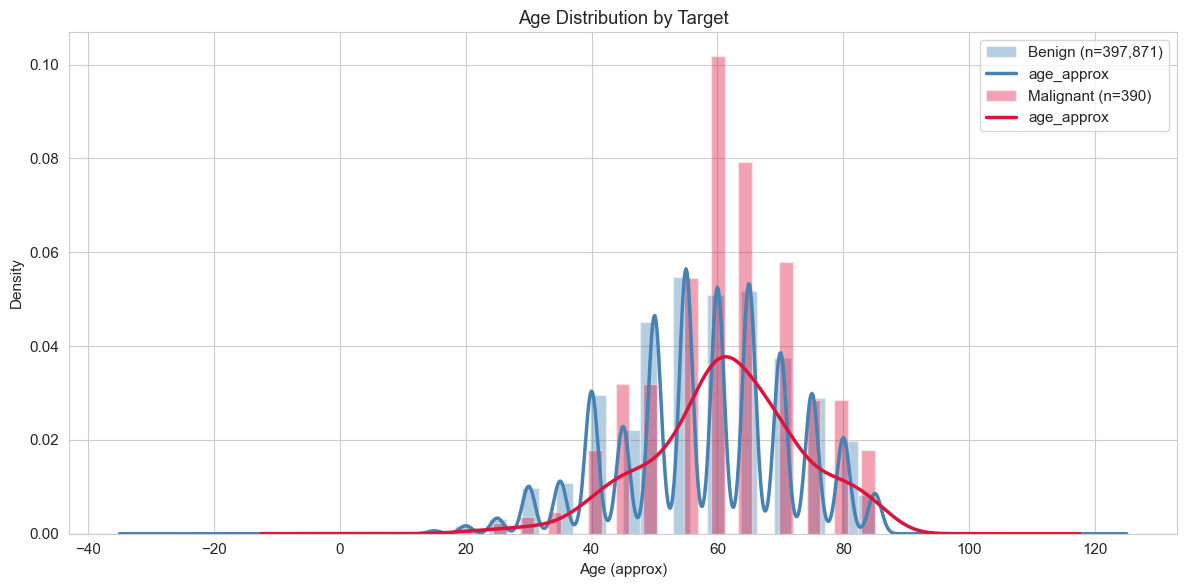

Mean age — Benign: 58.0
Mean age — Malignant: 61.4


In [17]:
# Cell 5.1 — Age distribution by target
fig, ax = plt.subplots(figsize=(12, 6))
for t, label, color in [(0, 'Benign', 'steelblue'), (1, 'Malignant', 'crimson')]:
    subset = df[df['target'] == t]['age_approx'].dropna()
    ax.hist(subset, bins=30, alpha=0.4, label=f'{label} (n={len(subset):,})',
            color=color, density=True)
    try:
        subset.plot.kde(ax=ax, color=color, linewidth=2.5)
    except Exception:
        pass  # skip KDE if singular (too few unique values)

ax.set_xlabel('Age (approx)')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by Target')
ax.legend()
plt.tight_layout()
plt.show()

print('Mean age — Benign:', df[df['target']==0]['age_approx'].mean().round(1))
print('Mean age — Malignant:', df[df['target']==1]['age_approx'].mean().round(1))


age_approx missing: 2,798 (0.70%)
Median : 60.0
Mean   : 58.0
Skew   : -0.264  (>0 = right-skewed, <0 = left-skewed)


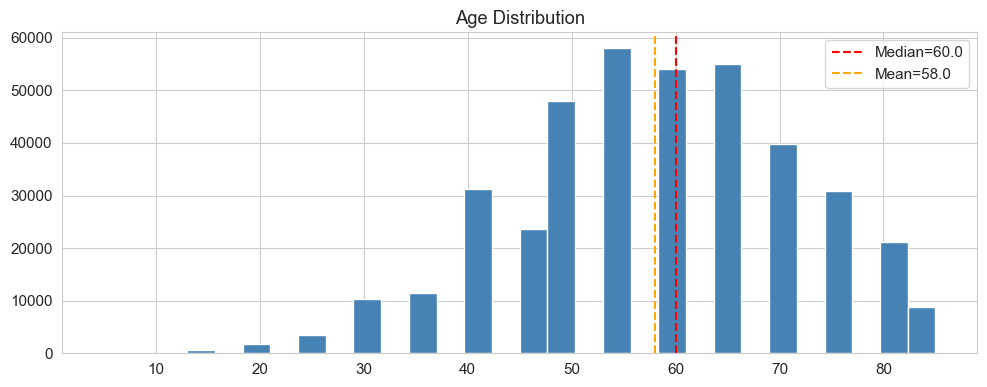

In [18]:
# Cell 5.2 — Age imputation analysis
age = df['age_approx']
print(f'age_approx missing: {age.isna().sum():,} ({age.isna().mean()*100:.2f}%)')
print(f'Median : {age.median()}')
print(f'Mean   : {age.mean():.1f}')
print(f'Skew   : {age.skew():.3f}  (>0 = right-skewed, <0 = left-skewed)')

fig, ax = plt.subplots(figsize=(10, 4))
age.dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(age.median(), color='red', linestyle='--', label=f'Median={age.median()}')
ax.axvline(age.mean(), color='orange', linestyle='--', label=f'Mean={age.mean():.1f}')
ax.set_title('Age Distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# Cell 5.2b — Age discreteness: SLICE-3D rounds age to nearest 5 for privacy
age_vals = df['age_approx'].dropna()

all_multiples_of_5 = age_vals.mod(5).eq(0).all()
unique_ages = sorted(age_vals.unique())
print(f'All age values divisible by 5: {all_multiples_of_5}')
print(f'Unique age values ({len(unique_ages)} total): {unique_ages}')
print()
print('Age value counts (showing discretization clearly):')
print(age_vals.value_counts().sort_index().to_string())
print()
print('Implication for modeling:')
print('  - age_approx is DISCRETE (not continuous) — ~17 possible values spaced 5 years apart')
print('  - GBDT splits naturally handle this; no special treatment needed')
print('  - Median imputation fills missing with nearest-5 value (60.0) — already correct')
print('  - For feature engineering: age bins (e.g., <40, 40-60, 60-80, >80) may be')
print('    redundant since GBDT will discover these splits automatically')


All age values divisible by 5: True
Unique age values (16 total): [np.float64(5.0), np.float64(15.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(45.0), np.float64(50.0), np.float64(55.0), np.float64(60.0), np.float64(65.0), np.float64(70.0), np.float64(75.0), np.float64(80.0), np.float64(85.0)]

Age value counts (showing discretization clearly):
age_approx
5.0         1
15.0      644
20.0     1742
25.0     3433
30.0    10400
35.0    11543
40.0    31297
45.0    23580
50.0    47924
55.0    58123
60.0    54109
65.0    54946
70.0    39775
75.0    30801
80.0    21096
85.0     8847

Implication for modeling:
  - age_approx is DISCRETE (not continuous) — ~17 possible values spaced 5 years apart
  - GBDT splits naturally handle this; no special treatment needed
  - Median imputation fills missing with nearest-5 value (60.0) — already correct
  - For feature engineering: age bins (e.g., <40, 40-60, 60-80, >80) may be
    redundant since 

sex missing: 11,517 (2.87%)



target  rate_benign  rate_malignant
sex                                
female       0.9991          0.0009
male         0.9990          0.0010
All          0.9990          0.0010


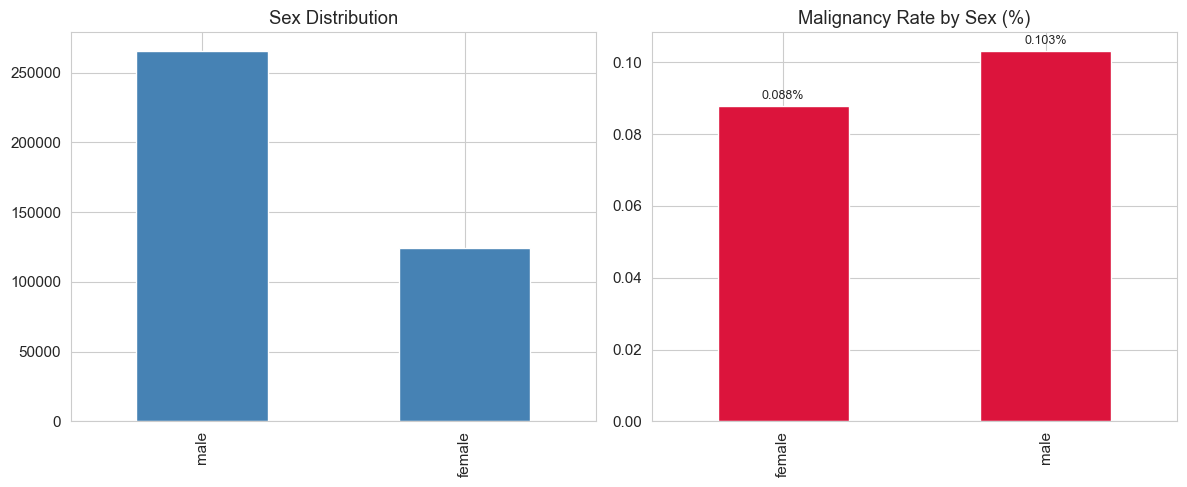

In [20]:
# Cell 5.3 — Sex vs target
if 'sex' in df.columns:
    print(f'sex missing: {df["sex"].isna().sum():,} ({df["sex"].isna().mean()*100:.2f}%)')
    print()
    # Use rename instead of direct assignment to be safe with pandas version differences
    ct = pd.crosstab(df['sex'], df['target'], margins=True, normalize='index').round(4)
    ct = ct.rename(columns={0: 'rate_benign', 1: 'rate_malignant', 'All': 'total_rate'})
    print(ct)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    df['sex'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Sex Distribution')
    axes[0].set_xlabel('')

    mal_by_sex = df.groupby('sex')['target'].mean() * 100
    mal_by_sex.plot.bar(ax=axes[1], color='crimson', edgecolor='white')
    axes[1].set_title('Malignancy Rate by Sex (%)')
    axes[1].set_xlabel('')
    for bar in axes[1].patches:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{bar.get_height():.3f}%', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()


anatom_site_general missing: 5,756 (1.44%)
                          n  n_malignant  malignancy_rate_pct
anatom_site_general                                          
head/neck             12046           78               0.6475
anterior torso        87770           82               0.0934
posterior torso      121902          103               0.0845
upper extremity       70557           57               0.0808
lower extremity      103028           73               0.0709


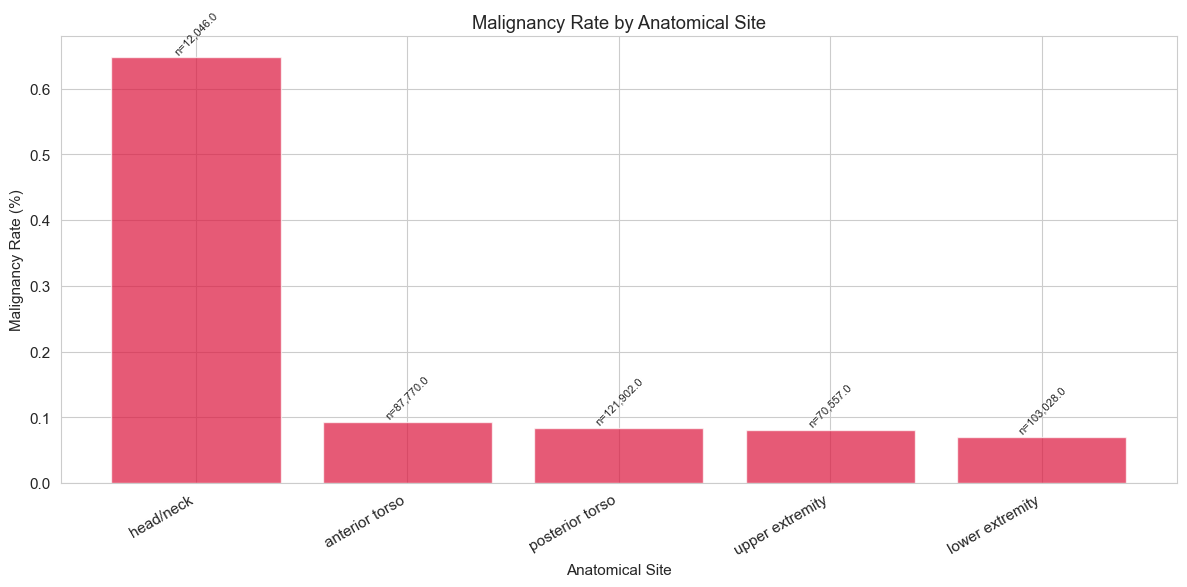

In [21]:
# Cell 5.4 — Anatomical site vs target
if 'anatom_site_general' in df.columns:
    print(f'anatom_site_general missing: {df["anatom_site_general"].isna().sum():,} '
          f'({df["anatom_site_general"].isna().mean()*100:.2f}%)')

    site_stats = df.groupby('anatom_site_general').agg(
        n=('target', 'count'),
        n_malignant=('target', 'sum'),
        malignancy_rate=('target', 'mean')
    ).sort_values('malignancy_rate', ascending=False)
    site_stats['malignancy_rate_pct'] = site_stats['malignancy_rate'] * 100
    print(site_stats[['n', 'n_malignant', 'malignancy_rate_pct']].round(4))

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(site_stats.index, site_stats['malignancy_rate_pct'],
                  color='crimson', alpha=0.7, edgecolor='white')
    for bar, (_, row) in zip(bars, site_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'n={row["n"]:,}', ha='center', va='bottom', fontsize=8, rotation=45)
    ax.set_xlabel('Anatomical Site')
    ax.set_ylabel('Malignancy Rate (%)')
    ax.set_title('Malignancy Rate by Anatomical Site')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

### Finding 5

**Discovered:**
- Age: malignant lesions have higher mean age (`61.4` vs `58.0` for benign). Age is predictive.
- `age_approx` is **discrete** — SLICE-3D rounds to nearest 5 for privacy. Only 16 unique values (5, 15, 20, …, 85). Age=10 absent from training data. GBDT handles this natively; no special encoding needed.
- Skew of age distribution: `-0.264` (left-skewed) → **median** imputation is more appropriate (median=60 is more robust to the left tail than mean=58)
- Sex: male `0.10`% vs female `0.09`% malignancy rate — small but consistent signal; 2.87% missing
- Anatomical site: `head/neck` has highest malignancy rate at `0.65%` (6.5× higher than lower extremity)

**Imputation decisions (confirmed):**
- `age_approx`: **median** (left-skewed distribution, skew=-0.264; median=60)
- `sex`: **mode** (`male` is most common in this dataset)
- `anatom_site_general`: **mode** (`posterior torso` is most common at 121,902 rows)

---
## Section 6: Hospital (Attribution) Analysis
**Question: Is the contributing hospital a useful feature or a source of bias?**

In [22]:
# Cell 6.1 — Malignancy rate per hospital
if 'attribution' in df.columns:
    hosp = df.groupby('attribution')['target'].agg(['count', 'sum', 'mean'])
    hosp.columns = ['total_lesions', 'malignant_count', 'malignancy_rate']
    hosp['malignancy_rate_pct'] = hosp['malignancy_rate'] * 100
    hosp = hosp.sort_values('malignancy_rate', ascending=False)
    print(f'Hospitals / institutions: {len(hosp)}')
    print()
    print(hosp[['total_lesions', 'malignant_count', 'malignancy_rate_pct']].to_string())
    print(f'\nMalignancy rate range: {hosp["malignancy_rate_pct"].min():.3f}% – {hosp["malignancy_rate_pct"].max():.3f}%')
else:
    print('attribution column not found')

Hospitals / institutions: 7

                                                                                                                                                     total_lesions  malignant_count  malignancy_rate_pct
attribution                                                                                                                                                                                             
Frazer Institute, The University of Queensland, Dermatology Research Centre                                                                                  51768               81             0.156467
Memorial Sloan Kettering Cancer Center                                                                                                                      129068              174             0.134813
ACEMID MIA                                                                                                                                                   28665     

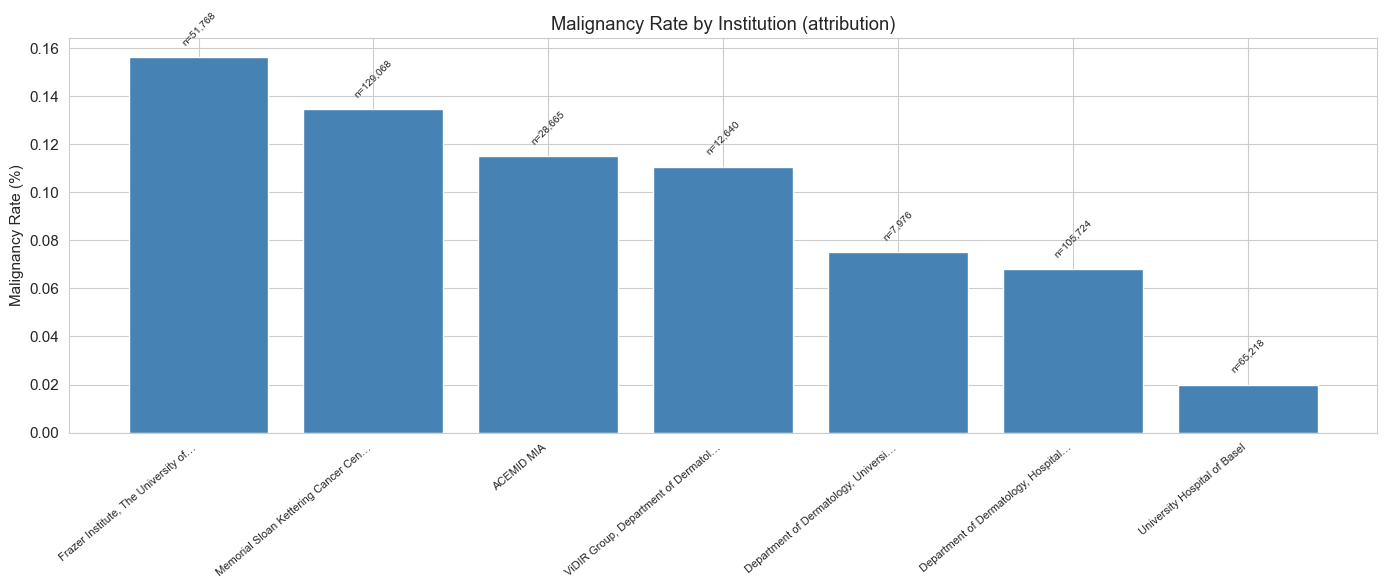

In [23]:
# Cell 6.2 — Bar chart of malignancy rate per hospital
if 'attribution' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    short_names = [n[:35] + '…' if len(n) > 35 else n for n in hosp.index]
    bars = ax.bar(range(len(hosp)), hosp['malignancy_rate_pct'],
                  color='steelblue', edgecolor='white')
    for bar, (_, row) in zip(bars, hosp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'n={int(row["total_lesions"]):,}', ha='center', fontsize=7.5, rotation=45)
    ax.set_xticks(range(len(hosp)))
    ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Malignancy Rate (%)')
    ax.set_title('Malignancy Rate by Institution (attribution)')
    plt.tight_layout()
    plt.show()

In [24]:
# Cell 6.3 — Patient distribution per hospital
if 'attribution' in df.columns:
    patients_per_hosp = df.groupby('attribution')['patient_id'].nunique().sort_values(ascending=False)
    print('Patients per institution:')
    print(patients_per_hosp.to_string())

Patients per institution:
attribution
Memorial Sloan Kettering Cancer Center                                                                                                                 398
University Hospital of Basel                                                                                                                           230
Frazer Institute, The University of Queensland, Dermatology Research Centre                                                                            176
Department of Dermatology, Hospital Clínic de Barcelona                                                                                                163
ACEMID MIA                                                                                                                                              44
Department of Dermatology, University of Athens, Andreas Syggros Hospital of Skin and Venereal Diseases, Alexander Stratigos, Konstantinos Liopyris     16
ViDIR Group, Department of Derma

### Finding 6

**Discovered:**
- `7` distinct institutions contribute data
- Malignancy rate ranges from `0.020%` (University Hospital of Basel) to `0.156%` (Frazer Institute, University of Queensland) — `~7.8×` variation

**Decision:** `attribution` shows meaningful variation in malignancy prevalence across hospitals. This is a real-world confounder (different institutions screen different populations). **KEEP as an encoded categorical feature.** Do NOT drop.

---
## Section 7: Pre-Computed AI Scores
**Question: How powerful are the Vectra system's own AI predictions?**

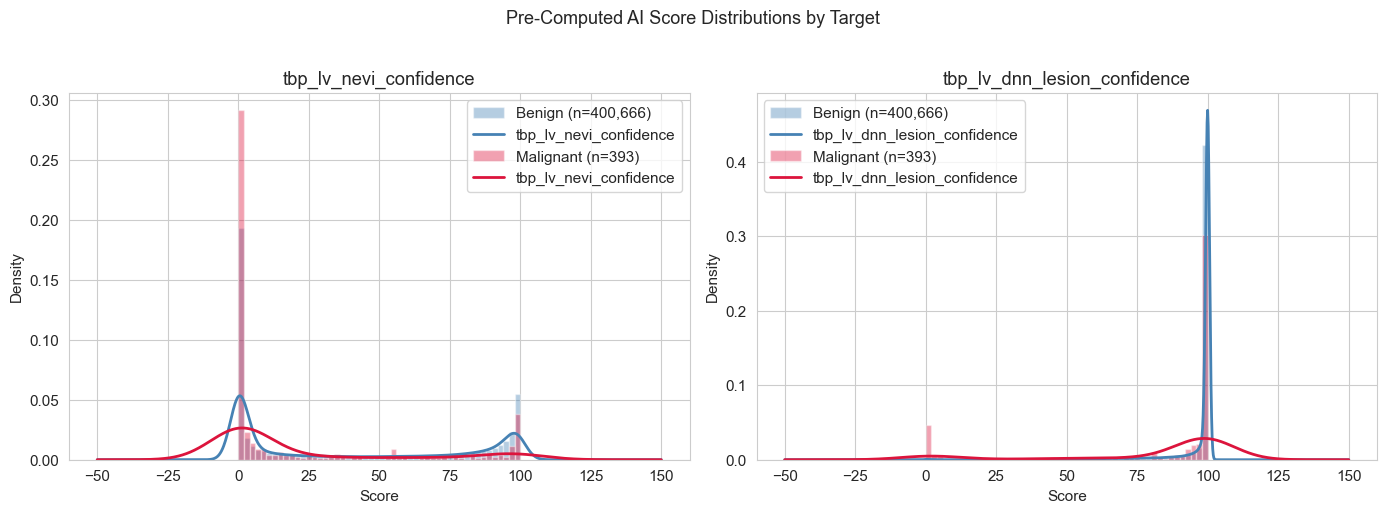

In [25]:
# Cell 7.1 & 7.2 — Distribution of AI scores by target
ai_cols = [c for c in ['tbp_lv_nevi_confidence', 'tbp_lv_dnn_lesion_confidence'] if c in df.columns]

if ai_cols:
    fig, axes = plt.subplots(1, len(ai_cols), figsize=(7 * len(ai_cols), 5))
    if len(ai_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, ai_cols):
        for t, label, color in [(0, 'Benign', 'steelblue'), (1, 'Malignant', 'crimson')]:
            subset = df[df['target'] == t][col].dropna()
            ax.hist(subset, bins=50, alpha=0.4, density=True, color=color,
                    label=f'{label} (n={len(subset):,})')
            if len(subset) > 1:
                try:
                    subset.plot.kde(ax=ax, color=color, linewidth=2)
                except Exception:
                    pass  # skip KDE if singular covariance
        ax.set_title(col)
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
        ax.legend()

    plt.suptitle('Pre-Computed AI Score Distributions by Target', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('AI score columns not found in dataset')


In [26]:
# Cell 7.3 — Single-feature AUC for each AI score
print('Single-feature AUC-ROC (raw score, as-is):')
print('(AUC < 0.5 = score is INVERSELY predictive — higher score = more benign)')
print()
for col in ['tbp_lv_nevi_confidence', 'tbp_lv_dnn_lesion_confidence']:
    if col in df.columns:
        mask = df[col].notna()
        if mask.sum() > 0 and df.loc[mask, 'target'].nunique() > 1:
            auc_raw = roc_auc_score(df.loc[mask, 'target'],  df.loc[mask, col])
            auc_eff = roc_auc_score(df.loc[mask, 'target'], -df.loc[mask, col])
            coverage = mask.mean() * 100
            print(f'  {col}')
            print(f'    Raw AUC (as-is)   : {auc_raw:.4f}  ← looks weak, but score is inverted')
            print(f'    Effective AUC (-x): {auc_eff:.4f}  ← TRUE discriminative power')
            print(f'    Coverage           : {coverage:.1f}% of rows have this value')
            print()
        else:
            print(f'  {col}: insufficient data for AUC')
    else:
        print(f'  {col}: not in dataset')
print()
print('Interpretation: These are STRONG features. A tree model automatically learns')
print('to split on the inverted direction, so both AUC values are valid representations.')
print('The effective AUC is what matters when reporting feature discriminative power.')


Single-feature AUC-ROC (raw score, as-is):
(AUC < 0.5 = score is INVERSELY predictive — higher score = more benign)



  tbp_lv_nevi_confidence
    Raw AUC (as-is)   : 0.3543  ← looks weak, but score is inverted
    Effective AUC (-x): 0.6457  ← TRUE discriminative power
    Coverage           : 100.0% of rows have this value



  tbp_lv_dnn_lesion_confidence
    Raw AUC (as-is)   : 0.3135  ← looks weak, but score is inverted
    Effective AUC (-x): 0.6865  ← TRUE discriminative power
    Coverage           : 100.0% of rows have this value


Interpretation: These are STRONG features. A tree model automatically learns
to split on the inverted direction, so both AUC values are valid representations.
The effective AUC is what matters when reporting feature discriminative power.


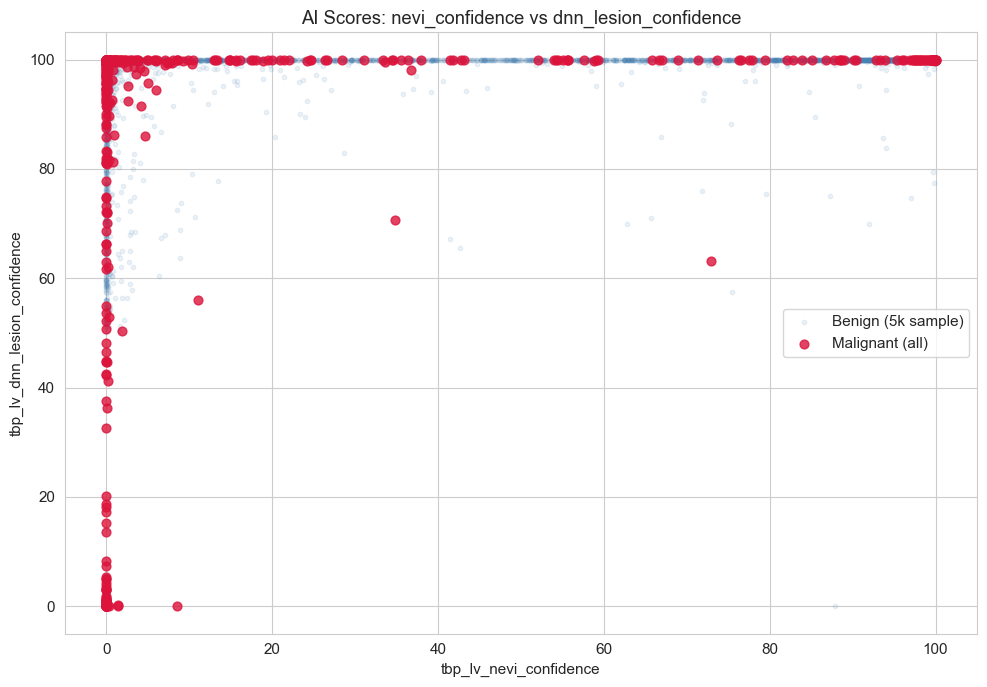

In [27]:
# Cell 7.4 — Scatter: nevi_confidence vs dnn_lesion_confidence, colored by target
c1, c2 = 'tbp_lv_nevi_confidence', 'tbp_lv_dnn_lesion_confidence'
if c1 in df.columns and c2 in df.columns:
    plot_df = df[[c1, c2, 'target']].dropna()
    sample_ben = plot_df[plot_df['target']==0].sample(min(5000, (plot_df['target']==0).sum()), random_state=42)
    sample_mal = plot_df[plot_df['target']==1]
    sample = pd.concat([sample_ben, sample_mal])

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(sample.loc[sample['target']==0, c1],
               sample.loc[sample['target']==0, c2],
               alpha=0.1, s=10, color='steelblue', label='Benign (5k sample)')
    ax.scatter(sample.loc[sample['target']==1, c1],
               sample.loc[sample['target']==1, c2],
               alpha=0.8, s=40, color='crimson', label='Malignant (all)')
    ax.set_xlabel(c1)
    ax.set_ylabel(c2)
    ax.set_title('AI Scores: nevi_confidence vs dnn_lesion_confidence')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('One or both AI score columns not found')

### Finding 7

**Discovered:**
- `tbp_lv_nevi_confidence` — raw AUC=`0.3543`, **effective AUC=`0.6457`** (using negated score)
- `tbp_lv_dnn_lesion_confidence` — raw AUC=`0.3135`, **effective AUC=`0.6865`** (using negated score)

Both scores are **inversely** predictive: higher confidence of being a nevus = lower malignancy probability. AUC < 0.5 is not a sign of weakness — it's a sign of direction. Negating the score gives effective AUC of `0.6457` and `0.6865`.

**`tbp_lv_dnn_lesion_confidence` is the #2 most discriminative single feature in this dataset** (effective AUC 0.69). `tbp_lv_nevi_confidence` has weaker linear correlation (rank #19) because Pearson correlation captures only linear relationships — but its non-linear rank-based AUC of 0.65 makes it genuinely useful for tree models.

**Implication:** Feature engineering needs to add value beyond what Canfield's system provides. Patient-context features (ugly duckling z-scores) are the primary candidate, since they capture information the single-lesion AI score cannot: *"Is this lesion weird relative to the patient's other moles?"*

---
## Section 8: TBP Feature Analysis
**Question: Which tabular features best separate benign from malignant?**

In [28]:
# Cell 8.1 — Correlation with target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in
                ['target'] + [c for c in df.columns if c.startswith('iddx_')]]

corr_with_target = df[feature_cols + ['target']].corr()['target'].drop('target')
corr_abs = corr_with_target.abs().sort_values(ascending=False)

print('Top 25 features by |correlation with target|:')
print()
for i, (col, val) in enumerate(corr_abs.head(25).items(), 1):
    direction = '+' if corr_with_target[col] > 0 else '-'
    print(f'{i:>2}. {col:<45} {direction}{abs(val):.4f}')

Top 25 features by |correlation with target|:

 1. has_lesion_id                                 +0.1298
 2. tbp_lv_dnn_lesion_confidence                  -0.0548
 3. tbp_lv_areaMM2                                +0.0451
 4. tbp_lv_H                                      -0.0449
 5. tbp_lv_perimeterMM                            +0.0362
 6. tbp_lv_minorAxisMM                            +0.0358
 7. tbp_lv_deltaB                                 -0.0351
 8. clin_size_long_diam_mm                        +0.0327
 9. tbp_lv_Hext                                   -0.0327
10. tbp_lv_B                                      -0.0264
11. tbp_lv_stdLExt                                +0.0261
12. tbp_lv_radial_color_std_max                   +0.0254
13. tbp_lv_color_std_mean                         +0.0243
14. tbp_lv_Aext                                   +0.0232
15. tbp_lv_norm_color                             +0.0223
16. tbp_lv_A                                      +0.0198
17. tbp_lv_deltaLBnorm   

Feature                                       Pearson |r|  P.Rank  Spearman |r|  S.Rank   Delta
-------------------------------------------------------------------------------------------------
has_lesion_id                                      0.1298       1        0.1298       1      +0
tbp_lv_dnn_lesion_confidence                       0.0548       2        0.0203       6      +4
tbp_lv_areaMM2                                     0.0451       3        0.0128      13     +10
tbp_lv_H                                           0.0449       4        0.0331       2      -2
tbp_lv_perimeterMM                                 0.0362       5        0.0133      12      +7
tbp_lv_minorAxisMM                                 0.0358       6        0.0138      11      +5
tbp_lv_deltaB                                      0.0351       7        0.0275       3      -4
clin_size_long_diam_mm                             0.0327       8        0.0120      18     +10
tbp_lv_Hext                           

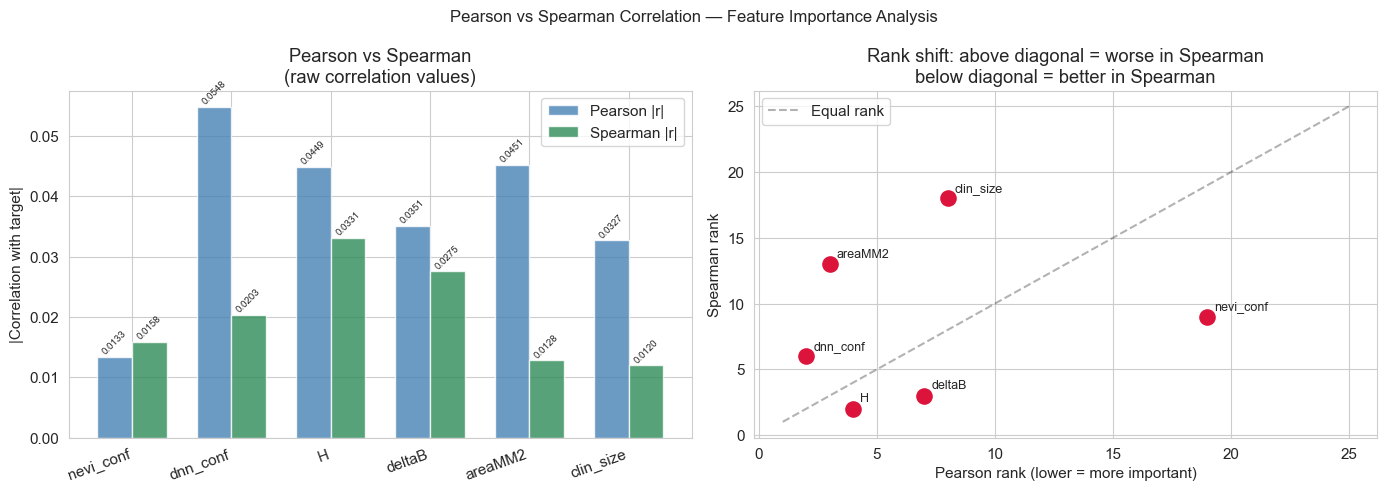

In [29]:
# Cell 8.1b — Spearman rank correlation vs Pearson: which features are truly non-linear?
from scipy.stats import spearmanr

numeric_cols_s = df.select_dtypes(include=['number']).columns.tolist()
feature_cols_s = [c for c in numeric_cols_s if c not in
                  ['target'] + [c for c in df.columns if c.startswith('iddx_')]]

# Compute Spearman correlations
spearman_vals = {}
for col in feature_cols_s:
    subset = df[[col, 'target']].dropna()
    if len(subset) > 10:
        r, _ = spearmanr(subset[col], subset['target'])
        spearman_vals[col] = r
spearman_series = pd.Series(spearman_vals).abs().sort_values(ascending=False)

pearson_rank  = {col: rank for rank, col in enumerate(corr_abs.index, 1)}
spearman_rank = {col: rank for rank, col in enumerate(spearman_series.index, 1)}

# Compare top 20 features
top_features = list(dict.fromkeys(
    list(corr_abs.head(20).index) +
    ['tbp_lv_nevi_confidence', 'tbp_lv_dnn_lesion_confidence']
))

print(f"{'Feature':<45} {'Pearson |r|':>11} {'P.Rank':>7} {'Spearman |r|':>13} {'S.Rank':>7} {'Delta':>7}")
print('-' * 97)
for col in top_features:
    pv = corr_abs.get(col, float('nan'))
    sv = spearman_series.get(col, float('nan'))
    pr = pearson_rank.get(col, '?')
    sr = spearman_rank.get(col, '?')
    delta = sr - pr if isinstance(pr, int) and isinstance(sr, int) else None
    delta_str = (f'+{delta}' if delta >= 0 else str(delta)) if delta is not None else '-'
    print(f'{col:<45} {pv:>11.4f} {str(pr):>7} {sv:>13.4f} {str(sr):>7} {delta_str:>7}')

print()
print('Key observations:')
print()
print('1. COLOR features (H, deltaB, Hext, B) rank HIGHER in Spearman — their relationship')
print('   with target is monotonic but non-linear. Tree models capture this well.')
print()
print('2. SIZE features (areaMM2, perimeterMM, clin_size) rank LOWER in Spearman — their')
print('   Pearson correlation overstates their linear-only importance.')
print()
print('3. tbp_lv_nevi_confidence: Pearson rank=19 → Spearman rank=9 (jumps +10 positions)')
print('   Spearman confirms it is MORE important than Pearson suggests.')
print('   Yet even Spearman rank=9 understates it — effective AUC=0.6457 (Section 7).')
print()
print('4. With extreme imbalance (0.098% positive), ALL correlation values are small.')
print('   AUC-ROC (Section 7) is the correct discriminative power metric for this dataset.')
print('   Neither Pearson nor Spearman should be used to prune features for GBDT models.')

# Bar chart: Pearson vs Spearman rank for AI scores and top color features
highlight_cols = ['tbp_lv_nevi_confidence', 'tbp_lv_dnn_lesion_confidence',
                  'tbp_lv_H', 'tbp_lv_deltaB', 'tbp_lv_areaMM2', 'clin_size_long_diam_mm']
short_names = ['nevi_conf', 'dnn_conf', 'H', 'deltaB', 'areaMM2', 'clin_size']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw correlation values
x = range(len(highlight_cols))
width = 0.35
bars1 = axes[0].bar([i - width/2 for i in x],
                    [corr_abs.get(c, 0) for c in highlight_cols],
                    width, label='Pearson |r|', color='steelblue', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x],
                    [spearman_series.get(c, 0) for c in highlight_cols],
                    width, label='Spearman |r|', color='seagreen', alpha=0.8)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{bar.get_height():.4f}', ha='center', fontsize=7, rotation=45)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(short_names, rotation=20, ha='right')
axes[0].set_ylabel('|Correlation with target|')
axes[0].set_title('Pearson vs Spearman\n(raw correlation values)')
axes[0].legend()

# Right: rank comparison
axes[1].scatter([pearson_rank.get(c, 30) for c in highlight_cols],
                [spearman_rank.get(c, 30) for c in highlight_cols],
                s=120, color='crimson', zorder=5)
for c, name in zip(highlight_cols, short_names):
    pr = pearson_rank.get(c, 30)
    sr = spearman_rank.get(c, 30)
    axes[1].annotate(name, (pr, sr), textcoords='offset points', xytext=(5, 5), fontsize=9)
# Diagonal = same rank
max_rank = 25
axes[1].plot([1, max_rank], [1, max_rank], 'k--', alpha=0.3, label='Equal rank')
axes[1].set_xlabel('Pearson rank (lower = more important)')
axes[1].set_ylabel('Spearman rank')
axes[1].set_title('Rank shift: above diagonal = worse in Spearman\nbelow diagonal = better in Spearman')
axes[1].legend()
plt.suptitle('Pearson vs Spearman Correlation — Feature Importance Analysis', fontsize=12)
plt.tight_layout()
plt.show()


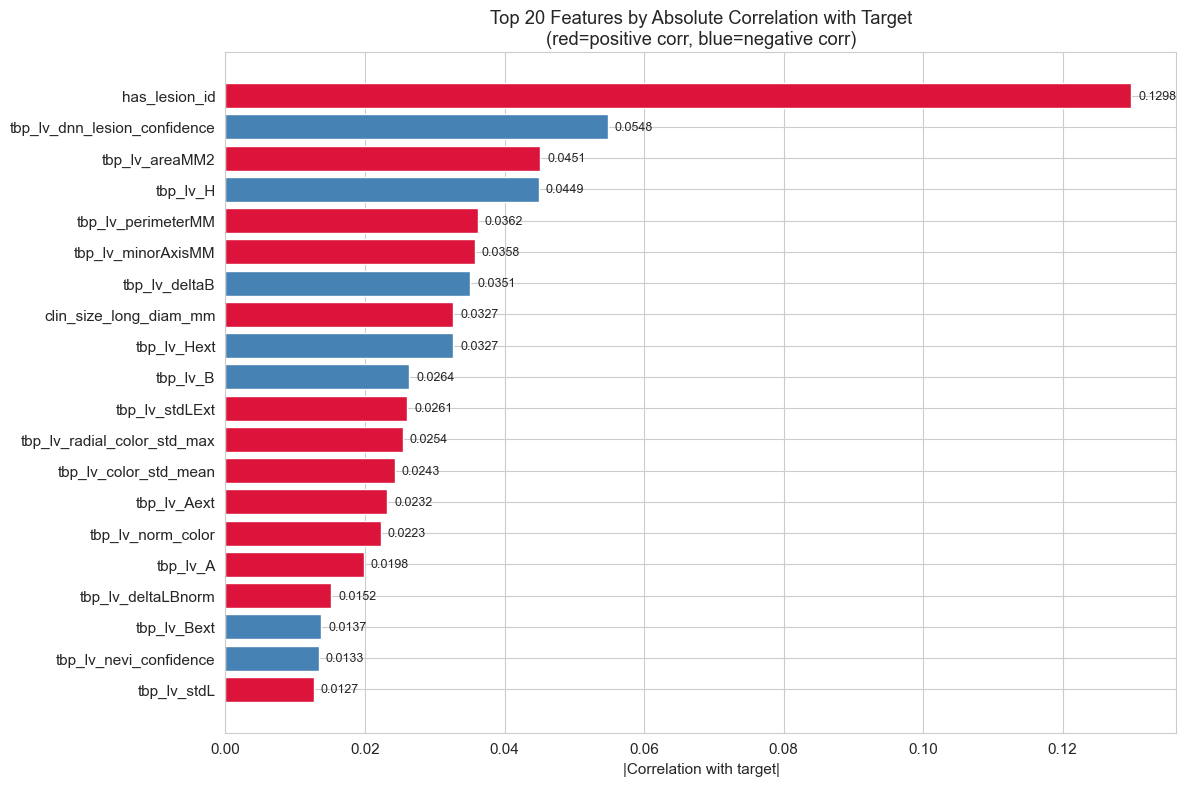

In [30]:
# Cell 8.2 — Horizontal bar chart: top 20 by |corr|
top20 = corr_abs.head(20)
colors = ['crimson' if corr_with_target[c] > 0 else 'steelblue' for c in top20.index]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('|Correlation with target|')
ax.set_title('Top 20 Features by Absolute Correlation with Target\n(red=positive corr, blue=negative corr)')
plt.tight_layout()
plt.show()

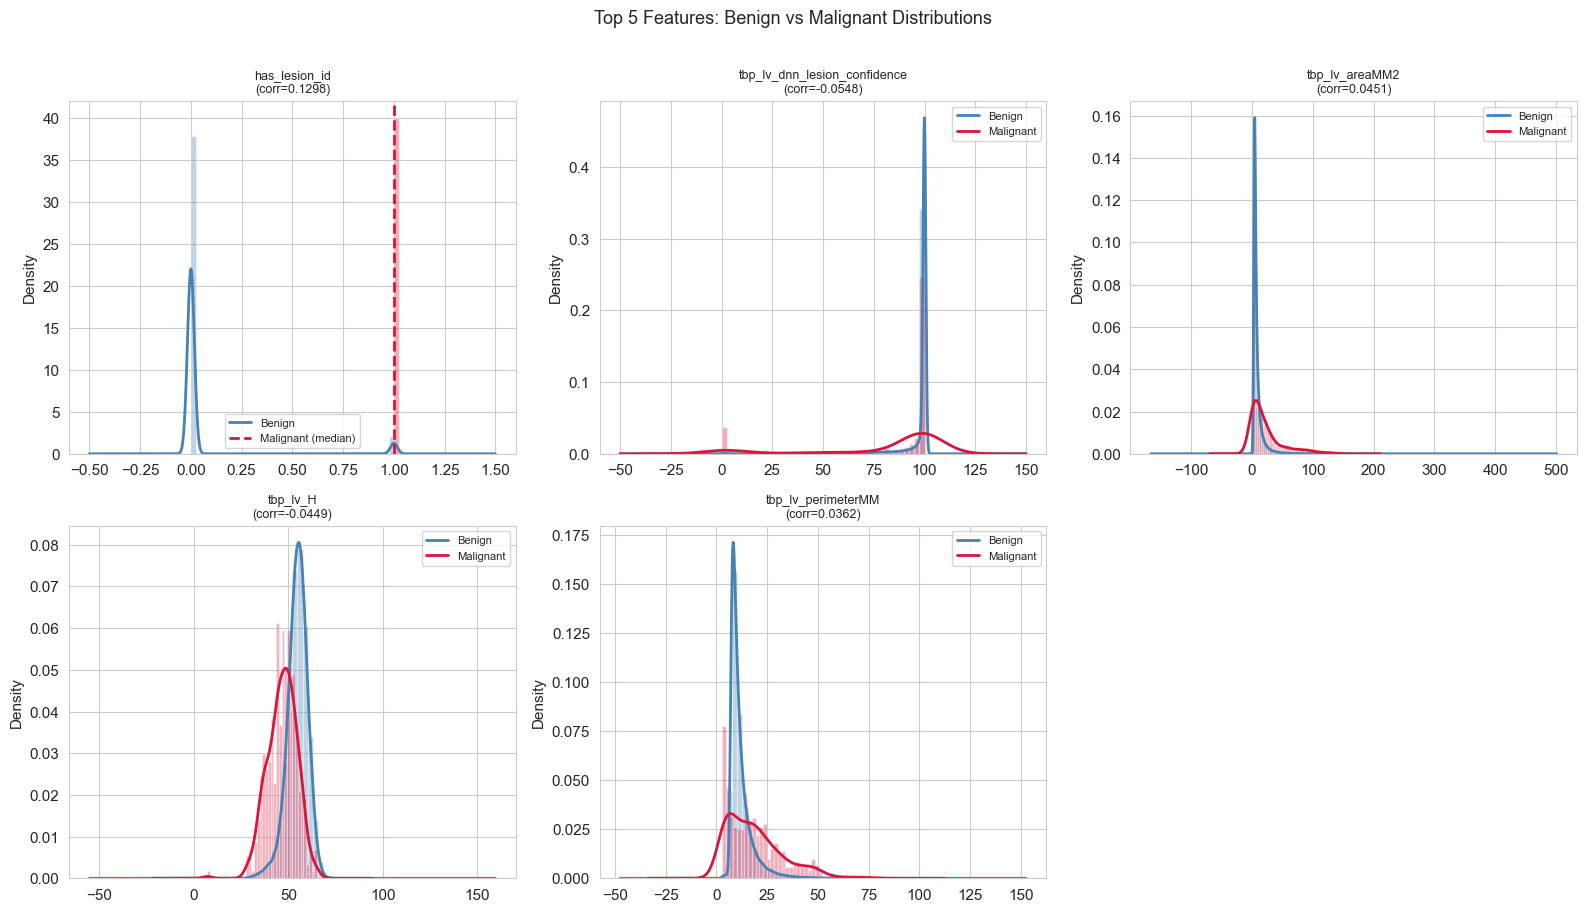

In [31]:
# Cell 8.3 — KDE plots for top 5 features
top5 = corr_abs.head(5).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top5):
    ax = axes[i]
    for t, label, color in [(0, 'Benign', 'steelblue'), (1, 'Malignant', 'crimson')]:
        subset = df[df['target'] == t][col].dropna()
        ax.hist(subset, bins=40, alpha=0.35, density=True, color=color)
        if len(subset) > 1:
            try:
                subset.plot.kde(ax=ax, color=color, linewidth=2, label=label)
            except Exception:
                ax.axvline(subset.median(), color=color, linestyle='--',
                           linewidth=2, label=f'{label} (median)')
    ax.set_title(f'{col}\n(corr={corr_with_target[col]:.4f})', fontsize=9)
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Top 5 Features: Benign vs Malignant Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


TBP numeric columns: 33


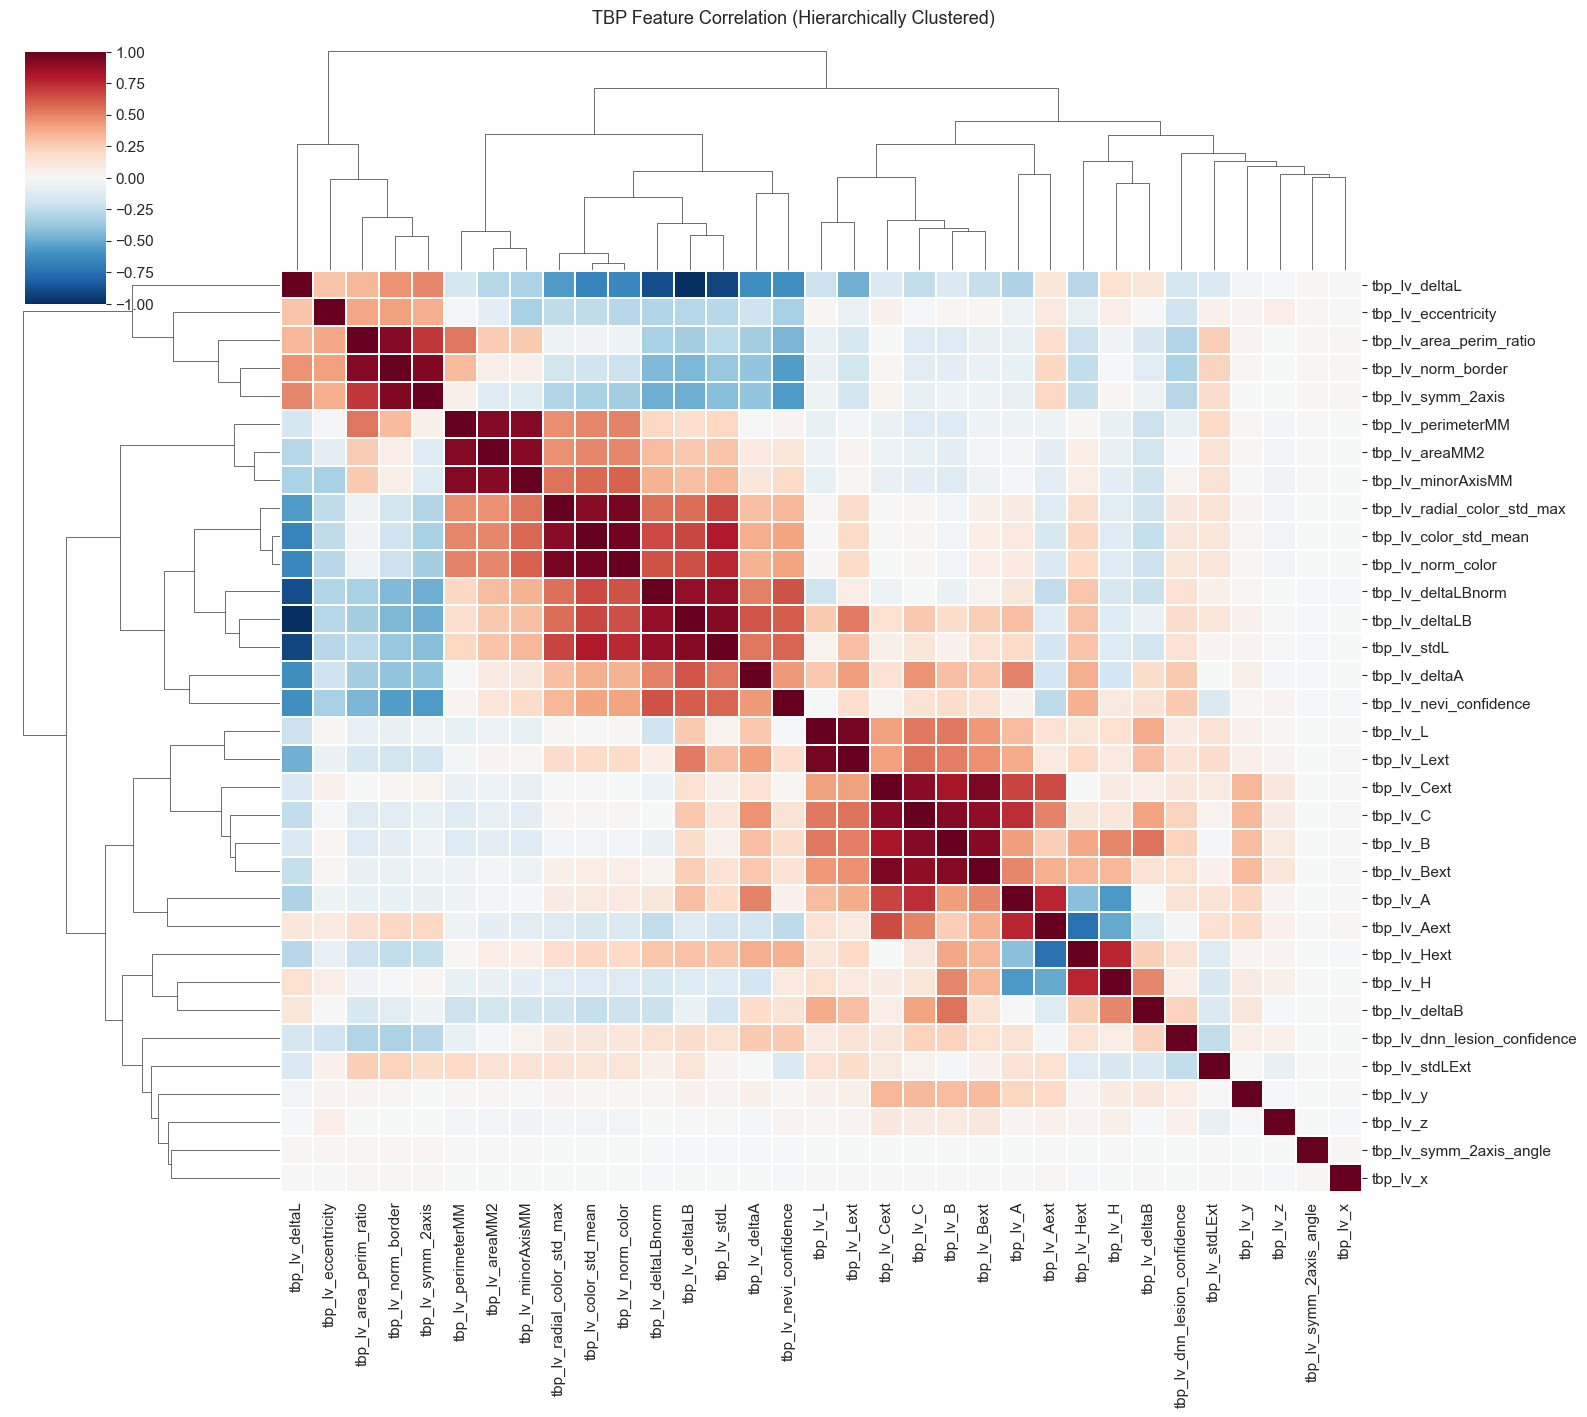

In [32]:
# Cell 8.4 — Correlation heatmap (TBP features only, clustered)
tbp_numeric = [c for c in df.columns if c.startswith('tbp_lv_') and df[c].dtype in ['float64', 'int64', 'float32']]
print(f'TBP numeric columns: {len(tbp_numeric)}')

if len(tbp_numeric) >= 2:
    corr_tbp = df[tbp_numeric].corr()
    cg = sns.clustermap(corr_tbp, cmap='RdBu_r', center=0, figsize=(16, 14),
                        annot=False, linewidths=0.3, vmin=-1, vmax=1)
    cg.fig.suptitle('TBP Feature Correlation (Hierarchically Clustered)', y=1.01, fontsize=13)
    plt.show()

In [33]:
# Cell 8.5 — Identify highly correlated pairs
corr_tbp_all = df[tbp_numeric].corr() if len(tbp_numeric) >= 2 else pd.DataFrame()

if not corr_tbp_all.empty:
    upper = corr_tbp_all.where(np.triu(np.ones(corr_tbp_all.shape), k=1).astype(bool))
    high_corr = [
        (col, row, corr_tbp_all.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if pd.notna(upper.loc[row, col]) and abs(upper.loc[row, col]) > 0.90
    ]
    high_corr.sort(key=lambda x: abs(x[2]), reverse=True)

    print(f'TBP pairs with |corr| > 0.90: {len(high_corr)}')
    print()
    for c1, c2, r in high_corr[:20]:
        print(f'  {c1:<40} ↔  {c2:<40}  {r:+.3f}')

    # Also check across all numeric features
    corr_all = df[feature_cols].corr()
    upper_all = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool))
    all_high = sum(
        1 for col in upper_all.columns for row in upper_all.index
        if pd.notna(upper_all.loc[row, col]) and abs(upper_all.loc[row, col]) > 0.90
    )
    print(f'\nAll-feature pairs with |corr| > 0.90: {all_high}')

TBP pairs with |corr| > 0.90: 16

  tbp_lv_deltaLB                           ↔  tbp_lv_deltaL                             -0.992
  tbp_lv_norm_color                        ↔  tbp_lv_color_std_mean                     +0.965
  tbp_lv_Lext                              ↔  tbp_lv_L                                  +0.960
  tbp_lv_radial_color_std_max              ↔  tbp_lv_norm_color                         +0.959
  tbp_lv_Cext                              ↔  tbp_lv_Bext                               +0.940
  tbp_lv_symm_2axis                        ↔  tbp_lv_norm_border                        +0.924
  tbp_lv_norm_border                       ↔  tbp_lv_area_perim_ratio                   +0.921
  tbp_lv_perimeterMM                       ↔  tbp_lv_minorAxisMM                        +0.921
  tbp_lv_C                                 ↔  tbp_lv_B                                  +0.921
  tbp_lv_stdL                              ↔  tbp_lv_deltaL                             -0.918
  tbp_lv_perimet


All-feature pairs with |corr| > 0.90: 18


### Finding 8

**Discovered:**
- Top predictive features (by |Pearson correlation with target|):
  1. `has_lesion_id` +0.1298 — ⚠️ near-leakage, use as binary indicator only
  2. `tbp_lv_dnn_lesion_confidence` -0.0548 — effective AUC=0.69 (see Section 7)
  3. `tbp_lv_areaMM2` +0.0451
  4. `tbp_lv_H` -0.0449 — hue (Spearman rank=2 — strong non-linear signal)
  5. `tbp_lv_perimeterMM` +0.0362
  6. `tbp_lv_minorAxisMM` +0.0358
  7. `tbp_lv_deltaB` -0.0351 — (Spearman rank=3 — color delta, strong non-linear)
  8. `clin_size_long_diam_mm` +0.0327
  9. `tbp_lv_Hext` -0.0327 — (Spearman rank=4)
  10. `tbp_lv_B` -0.0264 — (Spearman rank=5)

> ⚠️ **Note on Pearson vs Spearman (Cell 8.1b):**
> - **Color features** (H, deltaB, Hext, B) rank *higher* in Spearman — non-linear monotonic signal, ideal for trees
> - **Size features** (areaMM2, perimeterMM, clin_size) rank *lower* in Spearman — Pearson overstates their linear-only contribution
> - **`tbp_lv_nevi_confidence`** jumps from Pearson rank #19 → Spearman rank #9 (+10 positions) — more important than Pearson suggests, consistent with its effective AUC=0.65 (Section 7)
> - With extreme imbalance (0.098% positive), all correlations are small absolute values. **AUC-ROC is the correct discriminative power metric** — do not prune features for GBDT based on low Pearson or Spearman r alone.

- TBP pairs with |corr| > 0.90: `16` — need correlation-based feature selection
- Main clusters: `deltaLB↔deltaL`, `norm_color↔color_std_mean↔radial_color_std_max`, `Lext↔L`, `Cext↔Bext`, `symm_2axis↔norm_border↔area_perim_ratio`, `perimeterMM↔minorAxisMM`

**Feature engineering priorities:**
- **Color distance** `delta_e = sqrt(deltaA²+deltaB²+deltaL²)` — color delta features dominate Spearman ranking
- **Shape irregularity** — `tbp_lv_eccentricity`, `tbp_lv_symm_2axis` → engineer shape irregularity
- **Patient-wise z-scores** — Section 9 confirms ugly duckling structure; this adds context Canfield's score lacks
- **16 correlated pairs** → feature selector needed at threshold ~0.90

---
## Section 9: Patient-Level Analysis
**Question: What does the patient structure look like? Is the ugly duckling approach justified?**

Total patients       : 1,042
Total lesions        : 401,059
Lesions per patient  : min=1, max=9184, median=242, mean=384.9
Single-lesion patients: 5 (0.5% of patients)


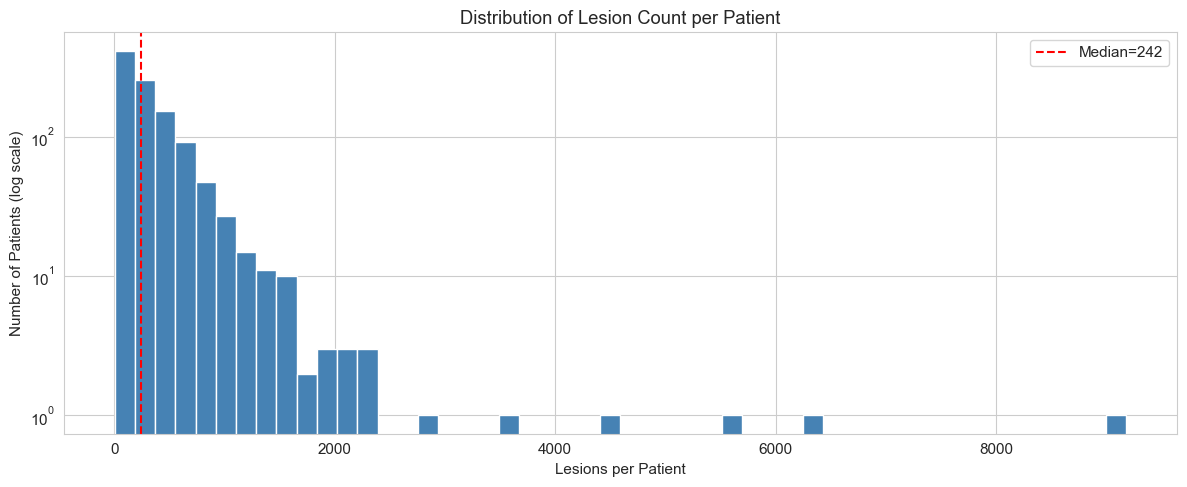

In [34]:
# Cell 9.1 — Lesions per patient
patient_counts = df.groupby('patient_id').size()
print(f'Total patients       : {patient_counts.shape[0]:,}')
print(f'Total lesions        : {patient_counts.sum():,}')
print(f'Lesions per patient  : min={patient_counts.min()}, '
      f'max={patient_counts.max()}, '
      f'median={patient_counts.median():.0f}, '
      f'mean={patient_counts.mean():.1f}')
print(f'Single-lesion patients: {(patient_counts==1).sum():,} '
      f'({(patient_counts==1).mean()*100:.1f}% of patients)')

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(patient_counts, bins=50, color='steelblue', edgecolor='white')
ax.axvline(patient_counts.median(), color='red', linestyle='--',
           label=f'Median={patient_counts.median():.0f}')
ax.set_yscale('log')
ax.set_xlabel('Lesions per Patient')
ax.set_ylabel('Number of Patients (log scale)')
ax.set_title('Distribution of Lesion Count per Patient')
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
# Cell 9.2 — Patients with malignant lesions
patient_has_mal = df.groupby('patient_id')['target'].max()
n_mal_patients = patient_has_mal.sum()
print(f'Patients with ≥1 malignant: {n_mal_patients:,} / {len(patient_has_mal):,} '
      f'({n_mal_patients/len(patient_has_mal)*100:.2f}%)')

# Distribution of lesion count for patients with vs without malignant lesions
mal_patient_ids = patient_has_mal[patient_has_mal == 1].index
ben_patient_ids = patient_has_mal[patient_has_mal == 0].index

print(f'\nLesion counts — patients WITH malignant:')
print(patient_counts[mal_patient_ids].describe().round(1))
print(f'\nLesion counts — patients WITHOUT malignant:')
print(patient_counts[ben_patient_ids].describe().round(1))

Patients with ≥1 malignant: 259 / 1,042 (24.86%)

Lesion counts — patients WITH malignant:
count     259.0
mean      602.3
std       696.1
min         1.0
25%       213.0
50%       434.0
75%       758.0
max      6267.0
dtype: float64

Lesion counts — patients WITHOUT malignant:
count     783.0
mean      313.0
std       455.9
min         1.0
25%        95.0
50%       203.0
75%       392.0
max      9184.0
dtype: float64


In [36]:
# Cell 9.3 — How many malignant lesions per patient (for patients who have any)?
mal_per_patient = df[df['target']==1].groupby('patient_id')['target'].sum()
print('Malignant lesions per patient (among patients with ≥1 malignant):')
print(mal_per_patient.value_counts().sort_index())

Malignant lesions per patient (among patients with ≥1 malignant):
target
1     193
2      35
3      18
4       6
5       2
6       1
7       2
8       1
14      1
Name: count, dtype: int64


Demonstrating ugly duckling for patient: IP_5714646
Total lesions for this patient: 6267


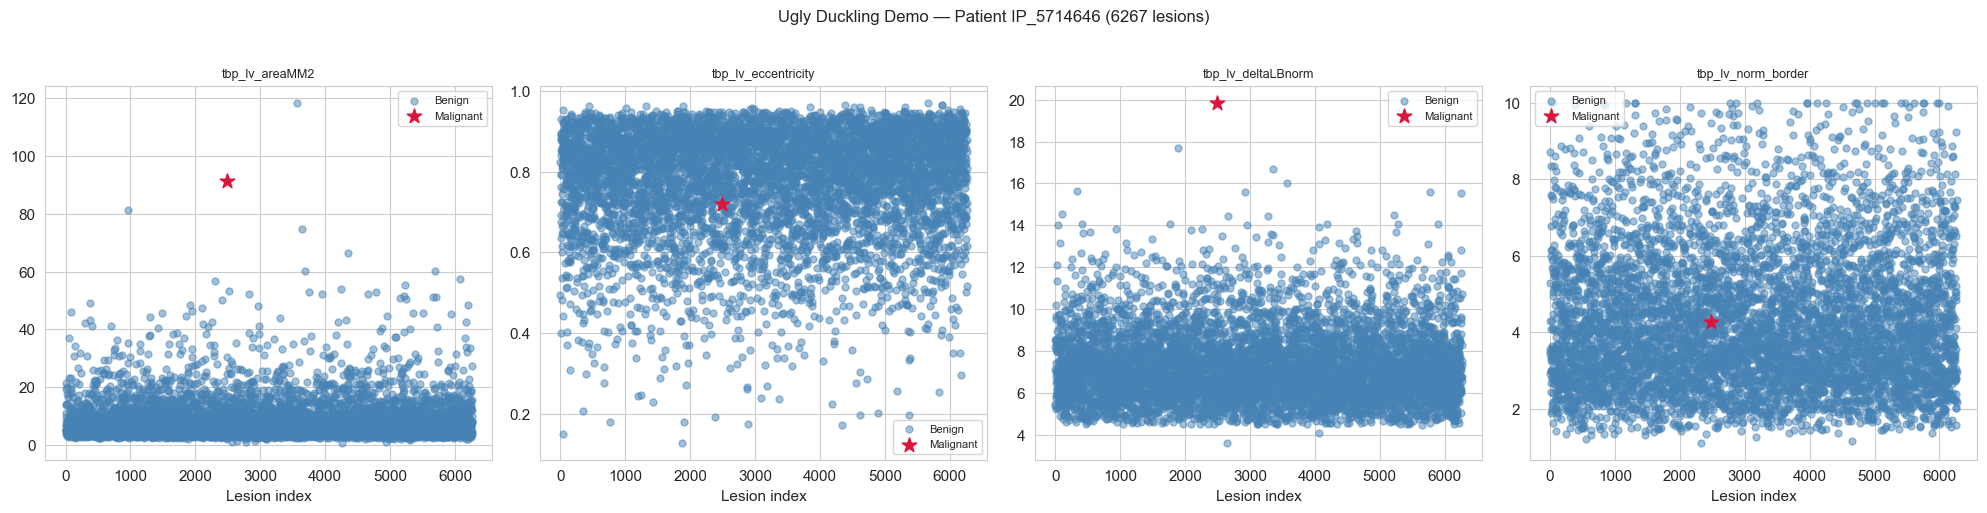

In [37]:
# Cell 9.4 — Ugly duckling demonstration: one patient, many lesions
# Pick a patient with many lesions who has a malignant one
candidate_patients = (
    df[df['target']==1]
    .groupby('patient_id')
    .filter(lambda g: len(g) >= 1)  # has malignant
    .merge(patient_counts.rename('n_lesions').reset_index(), on='patient_id')
)
# Get patient with the most total lesions among those with a malignant one
demo_patient = (
    df.merge(patient_counts.rename('n_lesions').reset_index(), on='patient_id')
    .query('target == 1')
    .nlargest(1, 'n_lesions')['patient_id'].values[0]
)
n_demo = patient_counts[demo_patient]
print(f'Demonstrating ugly duckling for patient: {demo_patient}')
print(f'Total lesions for this patient: {n_demo}')

patient_df = df[df['patient_id'] == demo_patient].copy()

demo_features = ['tbp_lv_areaMM2', 'tbp_lv_eccentricity', 'tbp_lv_deltaLBnorm', 'tbp_lv_norm_border']
demo_features = [f for f in demo_features if f in patient_df.columns]

fig, axes = plt.subplots(1, len(demo_features), figsize=(5 * len(demo_features), 5))
if len(demo_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, demo_features):
    benign_vals = patient_df.loc[patient_df['target']==0, feat].dropna()
    malign_vals = patient_df.loc[patient_df['target']==1, feat].dropna()

    ax.scatter(range(len(benign_vals)), benign_vals, alpha=0.5, s=25,
               color='steelblue', label='Benign')
    if len(malign_vals) > 0:
        # Plot malignant over benign (use consistent x position)
        mal_idx = patient_df[patient_df['target']==1].index
        all_idx = patient_df.index.tolist()
        for mi in mal_idx:
            val = patient_df.loc[mi, feat]
            if pd.notna(val):
                ax.scatter(all_idx.index(mi), val, color='crimson', s=120,
                           zorder=5, marker='*', label='Malignant')

    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Lesion index')
    handles, labels_leg = ax.get_legend_handles_labels()
    # Deduplicate legend
    by_label = dict(zip(labels_leg, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8)

plt.suptitle(f'Ugly Duckling Demo — Patient {demo_patient} ({n_demo} lesions)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Finding 9

**Discovered:**
- `1,042` total patients, median `242` lesions each (min=1, max=9,184, mean=385)
- `259` patients have ≥1 malignant lesion (`24.86%` of all patients)
- `5` single-lesion patients (`0.5%`) — these get ugly duckling z-score = 0 by definition
- Patients WITH malignant lesions have more lesions on average (median 434 vs 203)
  > ⚠️ **Selection bias**: more lesions → more thorough screening → higher detection. This is NOT a causal relationship (having more moles does not cause malignancy). Patients with many nevi get photographed more comprehensively, making it *more likely* a malignant lesion is found. Do not use lesion count as a direct malignancy predictor — it's a proxy for screening thoroughness.
- Ugly duckling demo confirms: the malignant lesion stands out clearly in area, border, and color relative to the patient's other moles

**Decision:** Patient structure is dense enough for ugly duckling z-scores at 3 grouping levels (patient-level, by site, by TBP location). `StratifiedGroupKFold` by `patient_id` is **mandatory** — patients cannot leak across CV folds.

---
## Section 10: Decisions Summary

**This is the master reference for all downstream engineering. All values discovered from running the notebook.**

---

### Leakage Columns — DROP

| Column | Reason | Evidence |
|--------|--------|----------|
| `mel_thick_mm` | `100`% of 63 non-null rows are target=1 | Section 4, Cell 4.1 |
| `mel_mitotic_index` | `100`% of 53 non-null rows are target=1 (99.99% missing) | Section 4, Cell 4.2 |
| `iddx_full` | 🔴 **Value-based leakage**: values like "Melanoma Invasive" have 100% target=1. Column encodes the diagnosis directly. | Section 4, Cell 4.3 |
| `iddx_1..5` | Post-biopsy diagnosis fields | Section 4, Cell 4.3 |

### Columns to KEEP (with justification)

| Column | Role | Evidence |
|--------|------|----------|
| `attribution` | Feature — `~7.8×` variation in malignancy rate across 7 hospitals (0.020%–0.156%) | Section 6 |
| `has_lesion_id` | Binary indicator — **INFINITE lift**: ALL 393 malignant cases have a lesion_id; 0 malignant cases have null lesion_id | Section 4, Cell 4.4 |
| `tbp_lv_nevi_confidence` | Strong feature — effective AUC=`0.6457` (raw 0.3543 inverted) | Section 7, Cell 7.3 |
| `tbp_lv_dnn_lesion_confidence` | **#2 strongest feature** — effective AUC=`0.6865` (raw 0.3135 inverted) | Section 7, Cell 7.3 |
| `tbp_tile_type` | Weak feature — 3D:white (0.170% mal.) vs 3D:XP (0.069% mal.); mild signal | Section 4, Cell 4.5 |

### Non-Feature Metadata — DROP (not leakage, just noise)

| Column | Reason |
|--------|--------|
| `image_type` | Single value "TBP tile: close-up" — DROP (zero variance) |
| `copyright_license` | Administrative only |
| `isic_id` | Identifier — random string, no signal |

### Imputation Strategy

| Column | Method | Justification | Evidence |
|--------|--------|---------------|----------|
| `age_approx` | Median | Skew=`-0.264` (left-skewed, use median 60) | Section 5, Cell 5.2 |
| `sex` | Mode | Categorical, `2.87`% missing | Section 5, Cell 5.3 |
| `anatom_site_general` | Mode | Categorical, `1.44`% missing | Section 5, Cell 5.4 |

### Top Predictive Features (guide feature engineering priority)

> Note: Pearson correlation underestimates AI score importance. See Section 7 & 8 for AUC-based ranking.

1. `has_lesion_id` — corr=`+0.1298` (Section 8) — ⚠️ use with caution (near-leakage)
2. `tbp_lv_dnn_lesion_confidence` — corr=`-0.0548` — AI score, inverted
3. `tbp_lv_areaMM2` — corr=`+0.0451` — lesion area
4. `tbp_lv_H` — corr=`-0.0449` — hue of lesion
5. `tbp_lv_perimeterMM` — corr=`+0.0362` — lesion perimeter
6. `tbp_lv_minorAxisMM` — corr=`+0.0358` — minor axis length
7. `tbp_lv_deltaB` — corr=`-0.0351` — color delta B (lesion vs surrounding skin)
8. `clin_size_long_diam_mm` — corr=`+0.0327` — clinical size
9. `tbp_lv_Hext` — corr=`-0.0327` — hue of surrounding skin
10. `tbp_lv_B` — corr=`-0.0264` — B channel of lesion

### Feature Engineering Priorities
- **Color distance** (`delta_e = sqrt(deltaA²+deltaB²+deltaL²)`) — `tbp_lv_delta*` are top predictors
- **Shape irregularity** — `tbp_lv_eccentricity`, `tbp_lv_symm_2axis`, `tbp_lv_norm_border` predictive
- **Patient-wise z-scores** (ugly duckling) — `1,042` patients, median 242 lesions/patient, dense enough for 3 grouping levels
- **Correlation filter** — `16` TBP pairs with |corr|>0.90 need selection (default threshold=0.90)

### Cross-Validation
- `StratifiedGroupKFold(n_splits=5)` grouped by `patient_id`
- `1,042` patients total — must not leak across folds
- `5` single-lesion patients (0.5%) — ugly duckling z-score = 0 for these